In [1]:
# read the data
import matplotlib.pyplot as plt
import numpy as np
#import pandas as pd
import matplotlib
import pandas as pd
import mne
import os
from mne.preprocessing import ICA
from scipy.stats import pearsonr
import seaborn as sns

In [2]:
## Some of the common function 
def identify_bad_channels(data, threshold=80e-6):
    """
    Identify bad channels based on amplitude difference exceeding the threshold.
    
    :param data: 3D array of shape (n_epochs, n_channels, n_times)
    :param threshold: Amplitude difference threshold in Volts (default: 80 microvolts)
    :return: List of bad channel indices
    """
    amplitude_diff = np.ptp(data, axis=2)  # peak-to-peak amplitude for each epoch and channel
    bad_channels = np.where(np.any(amplitude_diff > threshold, axis=0))[0]
    return bad_channels.tolist()


def remove_epochs_with_bad_mmn_channels(epochs, mmn_channels, amplitude_threshold=80e-6):
    """
    Remove epochs where MMN-related channels exceed the amplitude threshold.
    
    :param epochs: mne.Epochs object
    :param mmn_channels: List of MMN channel names
    :param amplitude_threshold: Amplitude difference threshold in Volts (default: 80 microvolts)
    :return: mne.Epochs object with bad epochs removed
    """
    data = epochs.get_data()
    
    bad_mmn_epochs = []
    for epoch_idx in range(len(epochs)):
        epoch_data = data[epoch_idx]
        epoch_bad_channels = identify_bad_channels(epoch_data[np.newaxis, :, :], amplitude_threshold)
        
        for ch_idx in epoch_bad_channels:
            ch_name = epochs.ch_names[ch_idx]
            if any(mmn_ch in ch_name for mmn_ch in mmn_channels):
                bad_mmn_epochs.append(epoch_idx)
                break
    
    good_epochs = np.setdiff1d(np.arange(len(epochs)), bad_mmn_epochs)
    return epochs[good_epochs]



# Combined Block 1 and 2 results

In [3]:

data_folder = r"D:\Work_data\Notification_evoked_response\Data_at_IITD/"
subjects = os.listdir(data_folder)
data_type = "EEG"
 # it is useful to scroll eeg data 
B1_MMN_erp_evoked_dict  = {}
B1_devi_eps_evoked_dict  = {}
B1_sta_eps_evoked_dict  = {}
B2_devi_eps_evoked_dict = {}
B2_sta_eps_evoked_dict = {}
B2_MMN_erp_evoked_dict = {}
epoch_per_num = {}
for sub in os.listdir(data_folder):
    path = os.path.join(data_folder,sub,data_type)
    
    for eeg in os.listdir(path):
        if eeg[-5:] == ".vhdr":
           
            raw = mne.io.read_raw_brainvision(os.path.join(path,eeg), preload=True)
            raw = mne.add_reference_channels(raw, ref_channels=["Cz"])
            raw.set_montage("easycap-M1")
            #raw.plot(scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue",event_color ='black',show_options=True )
            # Now re-reference the data :-n average reference 
            #raw.set_eeg_reference('average')
            raw.set_eeg_reference(ref_channels=['TP9', 'TP10'])
            raw.resample(512)

            #raw.plot(scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue",event_color ='black',show_options=True )
            # filter 
            raw.filter(l_freq=0.1,h_freq=30)
            #ICA 
            ica = ICA(n_components=20, random_state=97)
            ica.fit(raw)
            print("ICA Completed ...")
            #ica.plot_components()
            #removing Eye movement artifacts
            eog_channels = ['Fp1', 'Fp2', 'F7', 'F8']  # Adjust these to match your channel names
            eog_indices, eog_scores = ica.find_bads_eog(raw, ch_name=eog_channels)
            muscle_idx_auto, scores = ica.find_bads_muscle(raw)
            print(eog_indices, eog_scores , muscle_idx_auto, scores)
            ica.exclude = eog_indices + muscle_idx_auto
            ica.apply(raw)
            #raw.plot(scalings=dict(eeg=40e-6),clipping='transparent',duration=30.0, start=690.0, n_channels=63,color = "Blue" )
            events,event_dict = mne.events_from_annotations(raw)
            epochs = mne.Epochs(raw, events, event_id=[14,15,24,25],baseline=(None, 0), tmin=-0.300, tmax=0.700, preload=True)
            # Define your MMN channels
            mmn_channels = [ 'Fz', 'Cz','Pz']  #Example MMN channels, adjust as needed
            cleaned_epochs = remove_epochs_with_bad_mmn_channels(epochs, mmn_channels)
            try:
                cleaned_epochs.drop_channels(['GSR', 'PPG'])
            except:
                print("NO PPG sensor")
                pass
            print(f"Original number of epochs: {len(epochs)}")
            print(f"Number of epochs after removal: {len(cleaned_epochs)}")
            epoch_per_num[sub] = len(cleaned_epochs)
            try:
                B1_devi_eps = cleaned_epochs['15'].average()
                B1_sta_eps = cleaned_epochs["14"].average()
                B1_MMN_erp = mne.combine_evoked([ B1_devi_eps,B1_sta_eps], weights=[1,-1])
                evokeds = dict(B1_MMN_erp =B1_MMN_erp, B1_devi_eps= B1_devi_eps,B1_sta_eps=B1_sta_eps)  
            
                B1_devi_eps_evoked_dict[sub] = B1_devi_eps
                B1_sta_eps_evoked_dict[sub] = B1_sta_eps
                B1_MMN_erp_evoked_dict[sub] = B1_MMN_erp
                #mne.viz.plot_compare_evokeds(evokeds, picks=picks,title  = str (sub) + " BLock1 avaerage 'F3', 'Fz', 'F4'", combine="mean")

                # Block 2 

                B2_devi_eps = cleaned_epochs['25'].average()
                B2_sta_eps = cleaned_epochs["24"].average()
                B2_MMN_erp = mne.combine_evoked([ B2_devi_eps,B2_sta_eps], weights=[1,-1])
                evokeds = dict(B2_MMN_erp =B2_MMN_erp, B2_devi_eps= B2_devi_eps,B2_sta_eps=B2_sta_eps)  
            
                B2_devi_eps_evoked_dict[sub] = B2_devi_eps
                B2_sta_eps_evoked_dict[sub] = B2_sta_eps
                B2_MMN_erp_evoked_dict[sub] = B2_MMN_erp
            except:
                print("ERRor FOr epoching ") 

Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD011\EEG\sub011.vhdr...
Setting channel info structure...
Reading 0 ... 2431779  =      0.000 ...  2431.779 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequenc

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components


c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\sklearn\decomposition\_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Fitting ICA took 463.3s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Effective window size : 4.000 (s)
[0, 3] [array([-0.95709258,  0.10788755, -0.012977  , -0.26868871,  0.03541055,
       -0.08343508, -0.069148  ,  0.03190027,  0.01485166, -0.00433876,
        0.00740616, -0.00406814,  0.03559312,  0.02280494,  0.05383113,
        0.03710023, -0.05036596, -0.03339014,  0.04128498, -0.02805265]), array([-0.90695151,  0.06428927,  0.04648674, -0.38832032,  0.06114174,
       -0.05665551, -0.16756605,  0.04710402, -0.00442115,  0.04395266,
        0.00280806, -0.06536005,  0.01364757,  0.0375555 ,  0.01884014,
        0.00327998, -0.09649324, -0.05485023,  0.01611873, -0.02738976]), array([ 0.18054868,  0.09475508, -0.14567929, -0.81565981, -0.17937275,
       -0.28188422,  0.12568427, -0.09674056,  0.44851863, -0.22227616,
       -0.04711518,  0.34050362,  0.23589392, -0.10128896, -0.01169   ,
        0.32501861,  0.16579972, -0.10152853,  0.11121644, -0.23295125]), array([-0.8591196 , -0.07647237,  0.06982591, -0.34511898, -0.01596139,
        0.008083

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 1516
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD012\EEG\SD012.vhdr...
Setting channel info structure...
Reading 0 ... 2382059  =      0.000 ...  2382.059 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.6s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 15.4s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower t

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.6s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Effective window size : 4.000 (s)
[2] [array([ 0.00611   , -0.10665932,  0.95595778,  0.11010343,  0.02593211,
        0.13423289, -0.09767594,  0.08612343,  0.02187323,  0.01551557,
       -0.09550141,  0.15755914, -0.05168688, -0.04632076,  0.28094161,
       -0.16705336, -0.08822048,  0.16313754,  0.08407965,  0.06146383]), array([ 6.44977873e-04, -4.66164344e-02,  9.76055554e-01,  1.13914207e-01,
        2.30176954e-02,  7.61062304e-02, -1.52026982e-01,  1.04474806e-01,
        7.28084512e-02, -4.92229564e-02, -1.50837947e-01,  9.94563023e-02,
       -2.60338724e-02, -3.41039589e-02,  2.12713293e-01, -1.54167171e-01,
       -5.88109456e-02,  3.04708705e-02,  5.51555696e-02,  2.96399950e-02]), array([ 0.01048228, -0.19563325,  0.78029822, -0.09033117,  0.03565748,
        0.07627165,  0.03589416,  0.03339859, -0.14119099,  0.10949702,
        0.02342259,  0.24003572, -0.07096518, -0.05377248,  0.28664368,
       -0.15752488, -0.13810435,  0.42342388,  0.06491124,  0.12230636]), arra

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 1690
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD013\EEG\SD013.vhdr...
Setting channel info structure...
Reading 0 ... 2438619  =      0.000 ...  2438.619 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components


c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\sklearn\decomposition\_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Fitting ICA took 461.4s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.6s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.6s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.6s


Effective window size : 4.000 (s)
[6, 0] [array([-0.48360631, -0.28238009, -0.20974683, -0.1122067 ,  0.15753994,
       -0.08173081, -0.77096526,  0.20191247,  0.01910018, -0.07241363,
        0.10819572, -0.25099369,  0.0752427 ,  0.04197119, -0.13101806,
       -0.18628451, -0.1856812 ,  0.20703279, -0.17204271, -0.08751168]), array([-2.57878672e-01, -2.69900679e-01, -2.00028556e-01, -2.06674424e-01,
        5.31051018e-02, -2.44975283e-02, -8.93946292e-01,  2.13652306e-01,
        4.21339646e-02, -3.12809344e-02,  1.56862088e-01, -2.40712485e-01,
       -1.62951387e-03, -8.21220866e-04, -1.17492328e-02, -2.04335742e-01,
       -4.85019376e-02,  6.42530163e-02, -1.71728628e-01, -1.88671768e-01]), array([-0.53827264, -0.39765428, -0.22247752,  0.01158202,  0.17786917,
       -0.10378574, -0.53720204,  0.27307787, -0.07054412, -0.06551642,
       -0.08007116, -0.22231929,  0.16308223,  0.18626421, -0.32549595,
       -0.11962249, -0.40272499,  0.5011522 , -0.15451323,  0.13682155]), a

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 1736
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD014\EEG\SD014.vhdr...
Setting channel info structure...
Reading 0 ... 2368619  =      0.000 ...  2368.619 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 24.3s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower t

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


Effective window size : 4.000 (s)
[] [array([ 0.36908932,  0.53560243, -0.72608646, -0.14390808,  0.26164921,
        0.40186569,  0.31440429,  0.61212473, -0.22310396,  0.25332921,
       -0.19479161, -0.64895945, -0.33444274, -0.38454922, -0.37895365,
        0.18493987, -0.42335434, -0.439349  ,  0.28152105,  0.39631115]), array([ 0.34486277,  0.54176523, -0.61652018,  0.40491051,  0.15708804,
        0.52125958,  0.48716265,  0.47980855, -0.16490712,  0.02548136,
       -0.07591258, -0.47170522, -0.17579153, -0.27795055, -0.35866028,
        0.20138769,  0.02958849, -0.24128749,  0.22436395,  0.24693819]), array([ 0.62946634,  0.29454777, -0.55701309, -0.4043204 ,  0.30822718,
        0.23748895,  0.12268773,  0.6373641 ,  0.0015907 ,  0.18184749,
       -0.24139049, -0.70683855, -0.48274819, -0.13731397, -0.54990996,
        0.60627312, -0.3563413 , -0.57181494,  0.21996017,  0.43919305]), array([ 0.19343775,  0.27621468, -0.24490519,  0.62624631, -0.04399356,
        0.73535336, 

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 967
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD015\EEG\SD015.vhdr...
Setting channel info structure...
Reading 0 ... 2371899  =      0.000 ...  2371.899 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pas

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.6s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 37.2s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower t

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.6s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.6s


Effective window size : 4.000 (s)
[6] [array([ 0.24454692, -0.0681927 ,  0.10769095,  0.14127017, -0.15107777,
       -0.02553645,  0.89573976, -0.00495441, -0.03930081, -0.1167    ,
        0.24083558,  0.01735049, -0.03440171, -0.06589437, -0.13185758,
        0.00888893,  0.02512155,  0.11402555, -0.0852709 , -0.08812877]), array([ 0.3574989 , -0.07501863,  0.13042475,  0.02693901, -0.18358504,
        0.02116327,  0.86721677,  0.04223341, -0.18112001, -0.25752046,
        0.20855659,  0.07028851, -0.00212827, -0.1410439 , -0.19673625,
       -0.01500151, -0.00350418,  0.0656104 , -0.12686688, -0.10920591]), array([ 0.34394116, -0.05547593,  0.03876749,  0.32150697, -0.09342215,
       -0.10887797,  0.75672018, -0.07270297,  0.11000542,  0.09342716,
        0.1851322 ,  0.00703726, -0.09034463,  0.10701613, -0.07180685,
       -0.02533473,  0.00142707,  0.19499365, -0.09826493, -0.03227052]), array([ 0.67915138, -0.08132367,  0.1131271 , -0.18091484, -0.20403206,
        0.0769358 ,

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 1671
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD016\EEG\SD016.vhdr...
Setting channel info structure...
Reading 0 ... 2359659  =      0.000 ...  2359.659 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 47.2s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower t

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Effective window size : 4.000 (s)
[3] [array([-0.08061996,  0.14119172,  0.114083  ,  0.84071003,  0.40991732,
       -0.13089302, -0.03170467, -0.1714122 ,  0.19880306,  0.15772714,
       -0.05037365, -0.04681712, -0.16428002, -0.1024699 ,  0.26554757,
       -0.01937128,  0.10410655,  0.16736822, -0.03375583,  0.03553059]), array([ 8.79539382e-02,  1.40328635e-01,  9.73948209e-02,  7.90469330e-01,
        3.25873673e-01,  1.07205848e-02,  7.41660081e-02, -1.35711918e-01,
        4.69202987e-01,  2.29203148e-01, -1.06198818e-01,  3.68134112e-02,
       -1.93772749e-01, -3.19403461e-02,  2.70520391e-01, -7.76352640e-02,
        8.81800386e-02,  1.12138629e-01, -1.50342606e-01, -4.81018544e-04]), array([-0.12722022,  0.14959702,  0.08436109,  0.70400485,  0.29236372,
       -0.37721141, -0.05147436,  0.00730634, -0.27666025,  0.08388536,
       -0.02573752, -0.13829465,  0.00814455, -0.32219409,  0.17863547,
        0.14335712,  0.03174243,  0.34949098,  0.15039482,  0.11757894]), arra

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 1492
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD017\EEG\SD017.vhdr...
Setting channel info structure...
Reading 0 ... 2283419  =      0.000 ...  2283.419 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 42.3s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower t

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Effective window size : 4.000 (s)
[3] [array([ 0.20068845, -0.01041226,  0.02792401, -0.96350716,  0.04249593,
       -0.14207725,  0.01328061, -0.07362821, -0.04819618, -0.07693973,
       -0.03042464, -0.0535704 ,  0.00400279, -0.14115738,  0.01842892,
       -0.08837446,  0.1558138 ,  0.05143853, -0.16476423, -0.0139656 ]), array([ 0.35143578, -0.0340712 , -0.10156554, -0.87696595, -0.04529885,
       -0.15293143, -0.15649718, -0.3722766 , -0.0710294 , -0.05336406,
       -0.06833283,  0.0605804 ,  0.06253209, -0.11932119, -0.00590514,
       -0.05203418,  0.10047341,  0.05145268, -0.12426907, -0.03860733]), array([ 0.31269403,  0.1192428 ,  0.08032445, -0.69807147,  0.31026598,
       -0.02406243,  0.50870178, -0.06658626,  0.03928225, -0.2099126 ,
       -0.06161659, -0.22411642, -0.08177415, -0.12558929,  0.06600347,
       -0.21559093,  0.36013391,  0.05108303, -0.25829957, -0.01864883]), array([-0.36279417, -0.13042012, -0.10773828, -0.73267512, -0.13262701,
       -0.19055019,

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1742
Number of epochs after removal: 1531
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD018\EEG\SD018.vhdr...
Setting channel info structure...
Reading 0 ... 2414859  =      0.000 ...  2414.859 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 26.7s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower t

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Effective window size : 4.000 (s)
[1] [array([ 0.26615305, -0.92361908, -0.22801684,  0.36068213, -0.20150472,
        0.21376467,  0.02852486, -0.03653068,  0.0133465 ,  0.08320434,
       -0.03855016,  0.16355876,  0.06656839, -0.06427017,  0.0174416 ,
       -0.16568005, -0.05268013, -0.05279378,  0.08660864, -0.02939529]), array([ 0.11638545, -0.97826558, -0.22279685,  0.27424328, -0.20853813,
        0.0242991 ,  0.01338856, -0.06951277,  0.00869538,  0.04891009,
       -0.03082796,  0.1917206 ,  0.02884879, -0.08034542, -0.00671259,
       -0.18216995, -0.05295609, -0.04388462,  0.10503581, -0.01631435]), array([ 0.31675031, -0.68000944, -0.17463584,  0.19335897, -0.10260219,
        0.64098437,  0.01724308,  0.00715889,  0.00190824,  0.28473037,
       -0.01510468,  0.20476144,  0.25395802,  0.02339386,  0.06415335,
       -0.18385842, -0.00912687, -0.14239679,  0.03957277, -0.01456039]), array([ 0.04303958, -0.65226148, -0.12141173,  0.1319843 , -0.18013031,
       -0.66406358,

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 1605
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD019\EEG\SD019.vhdr...
Setting channel info structure...
Reading 0 ... 2360359  =      0.000 ...  2360.359 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 31.8s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower t

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Effective window size : 4.000 (s)
[] [array([-0.3634482 , -0.12847893, -0.21814031,  0.55705175,  0.37875341,
        0.10056922,  0.3824727 , -0.34909573,  0.20913726, -0.8485269 ,
       -0.3587014 ,  0.10192972,  0.87003295, -0.10188629, -0.66338252,
       -0.42270842, -0.3919821 ,  0.42696003, -0.15441227,  0.09205686]), array([-0.24919414, -0.02456241, -0.1244236 ,  0.51067373,  0.36826625,
        0.21028382,  0.24125395, -0.44713697,  0.30321934, -0.80365374,
       -0.33990549,  0.12949044,  0.88480844, -0.08673472, -0.72972262,
       -0.3886848 , -0.43152572,  0.34183251, -0.26519981,  0.15593342]), array([-0.48058102, -0.32916801, -0.32798949,  0.59568643,  0.28275799,
       -0.22581548,  0.57842691, -0.11083788, -0.14645334, -0.7513297 ,
       -0.25025577, -0.0918611 ,  0.63723035, -0.6011055 , -0.31936768,
       -0.38799089, -0.18243181,  0.35671536,  0.16097206, -0.08169772]), array([ 0.17327647,  0.31183654,  0.2388301 ,  0.23569483,  0.35838   ,
        0.15295313, 

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 1344
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD020\EEG\SD020.vhdr...
Setting channel info structure...
Reading 0 ... 2535859  =      0.000 ...  2535.859 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components


c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\sklearn\decomposition\_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Fitting ICA took 477.8s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Effective window size : 4.000 (s)
[1] [array([ 0.03473239, -0.90088512,  0.02138692,  0.10015469,  0.32956507,
        0.072505  ,  0.10959657,  0.43251436, -0.01145078, -0.0378782 ,
        0.23389308,  0.01565048, -0.02304556,  0.03329929,  0.08263841,
       -0.16419411, -0.22949202, -0.02288704,  0.07342584,  0.05936025]), array([ 0.02982328, -0.94068692, -0.09485417,  0.08766746,  0.34917864,
        0.11549779,  0.108605  ,  0.22774062, -0.04258012, -0.05322441,
        0.19173462,  0.01697914, -0.01064486, -0.00227   ,  0.0823291 ,
       -0.1361199 , -0.23165112, -0.03221697,  0.0737195 ,  0.04508615]), array([ 0.08439452, -0.61377794,  0.0441419 ,  0.09153785,  0.42812451,
       -0.09903273,  0.14335836,  0.67634328,  0.05884244, -0.01858527,
        0.27779026,  0.00713971, -0.16545889,  0.0547285 ,  0.02085965,
       -0.23566447, -0.2549718 , -0.02352147,  0.10124208,  0.1123426 ]), array([-0.06069737, -0.78383223, -0.05324936,  0.12352838,  0.53801324,
        0.09088793,

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 1743
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD021\EEG\SD021.vhdr...
Setting channel info structure...
Reading 0 ... 2422699  =      0.000 ...  2422.699 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 62.4s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower t

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.6s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Effective window size : 4.000 (s)
[] [array([-0.32650062,  0.49546427,  0.36047279,  0.31730042,  0.11427761,
        0.21701199,  0.76582632, -0.24071356,  0.10673819, -0.16240349,
       -0.19081608,  0.07415192,  0.19857383,  0.00482554,  0.04713968,
        0.18384823, -0.03574269, -0.28236467,  0.10015419, -0.1996129 ]), array([-0.3541428 ,  0.48663024,  0.35768   ,  0.33355408,  0.10416714,
        0.24318871,  0.78036911, -0.23567412, -0.07995966, -0.15387646,
       -0.18343294,  0.11078065,  0.16547347, -0.01566825,  0.06154652,
        0.20591873, -0.10350519, -0.27826305,  0.0946344 , -0.18276637]), array([-0.31949146,  0.68708873,  0.26455078,  0.18767474,  0.11816841,
        0.02969974,  0.46920574, -0.25858677,  0.36548073, -0.11985657,
       -0.15329032,  0.03138788,  0.34301576, -0.07014185,  0.04052106,
        0.12024292,  0.1579211 , -0.23512381,  0.08455732, -0.15522183]), array([-0.28312488,  0.61533322,  0.23390447,  0.29893889,  0.00102706,
        0.17788011, 

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 1517
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD022\EEG\SD022.vhdr...
Setting channel info structure...
Reading 0 ... 2361559  =      0.000 ...  2361.559 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\2324062902.py:32: RuntimeWarning: Using n_components=20 (resulting in n_components_=20) may lead to an unstable mixing matrix estimation because the ratio between the largest (64) and smallest (3.9e-06) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 4
  ica.fit(raw)


Fitting ICA took 29.3s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition b

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Effective window size : 4.000 (s)
[8] [array([-1.07379381e-02, -2.41046291e-01, -3.44619098e-01, -6.65158394e-04,
        1.54232205e-01, -1.59254586e-01, -2.02122738e-02,  4.96048705e-02,
       -8.97134297e-01, -1.66100132e-01,  3.29718908e-02,  1.79578728e-01,
        4.14166844e-02, -1.68664165e-02, -1.03089448e-01, -8.56017038e-03,
        1.45856267e-01, -8.65810774e-03,  5.45692962e-01, -2.41949414e-01]), array([-0.01577834, -0.35780832, -0.36966936, -0.03112273,  0.121746  ,
       -0.11706769,  0.04240752,  0.0096251 , -0.89175491, -0.16490121,
        0.02025417,  0.23813887,  0.12654001, -0.01904002, -0.12243205,
        0.00892017,  0.12831334, -0.03916008,  0.56713402, -0.0624263 ]), array([-0.01373032, -0.21327575, -0.19043156,  0.1262785 , -0.0029536 ,
       -0.21797695, -0.04743395,  0.05489411, -0.68791764, -0.27912609,
        0.141909  ,  0.22680496,  0.07374956, -0.0556941 , -0.25842025,
        0.17890194,  0.27729943,  0.14705687,  0.19867299, -0.58895341]), arra

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 1780
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD023\EEG\SD023.vhdr...
Setting channel info structure...
Reading 0 ... 2398319  =      0.000 ...  2398.319 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.6s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 45.7s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower t

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.6s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.6s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.6s


Effective window size : 4.000 (s)
[1] [array([-3.45469711e-02, -9.90568570e-01,  8.18761340e-02, -2.86575701e-02,
        1.61886319e-04, -1.10261012e-01, -1.91843243e-02,  4.77833737e-02,
       -7.99250132e-03,  1.06443188e-01, -4.35880402e-02,  3.98681823e-03,
        9.71135969e-02, -1.45875684e-01, -4.13552608e-02, -1.38827588e-01,
        8.63609205e-02, -9.40589576e-02, -9.77567426e-02, -1.11621683e-01]), array([-0.03039666, -0.99458185,  0.08434664, -0.03371486, -0.01843589,
       -0.08576093, -0.06161679,  0.04347975, -0.00721317,  0.10825168,
        0.03214758, -0.00863851,  0.09157074, -0.1357834 , -0.0475522 ,
       -0.13119442,  0.07017685, -0.09199204, -0.09408194, -0.12246752]), array([-0.05865844, -0.86740777,  0.0428862 ,  0.01780086,  0.11680544,
       -0.21991453,  0.04068946,  0.06211748, -0.01363461,  0.28740395,
       -0.30656603,  0.1075662 ,  0.14107535, -0.23813921, -0.07196465,
       -0.18134631,  0.05904147, -0.15460999, -0.17147066, -0.11573335]), arra

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 1698
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD024\EEG\SD024.vhdr...
Setting channel info structure...
Reading 0 ... 2366679  =      0.000 ...  2366.679 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 62.5s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower t

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


Effective window size : 4.000 (s)
[2] [array([ 0.25482459, -0.33733408, -0.73893234,  0.05111809,  0.03627967,
        0.16608024,  0.30642292, -0.24493889, -0.06770395, -0.07977554,
        0.55156392,  0.07891178, -0.05285916, -0.17271675, -0.00538244,
       -0.01115411,  0.13728328,  0.04776729, -0.02493615, -0.01346501]), array([ 0.02446856, -0.18807137, -0.96948197,  0.03284154,  0.01628439,
        0.10951686,  0.05255552,  0.00122283, -0.15032905, -0.07847858,
        0.15891836,  0.03707614,  0.00677542, -0.04482946,  0.05755329,
       -0.03868058, -0.03681247, -0.11277714,  0.00824285,  0.04591011]), array([-2.36581659e-02, -9.24316973e-02, -8.19444259e-01,  1.76296867e-04,
       -1.18226138e-01, -3.78691119e-02, -2.78065375e-02, -1.10048393e-01,
       -1.27406694e-01,  3.11048881e-02,  3.17622531e-01,  1.91460828e-01,
        1.19219869e-01, -2.08857531e-01, -3.34610095e-01, -1.10731409e-02,
       -6.43075396e-02, -1.02179865e-01, -1.89632978e-01,  8.86022901e-02]), arra

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 1691
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD025\EEG\SD025.vhdr...
Setting channel info structure...
Reading 0 ... 2372779  =      0.000 ...  2372.779 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 28.4s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.6s


Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.6s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.6s


Effective window size : 4.000 (s)
[4] [array([-0.17314763,  0.26862246, -0.10774529, -0.00671187,  0.88796525,
       -0.03210346,  0.11477477, -0.31772391,  0.09190281,  0.00146604,
       -0.04426545,  0.17052319,  0.24893897, -0.13290901,  0.01966916,
       -0.14202828, -0.07307114,  0.13283664, -0.09326788, -0.10578469]), array([-0.1184299 ,  0.26730636, -0.31604744,  0.02550412,  0.87051763,
       -0.01162143,  0.09734672, -0.30295869,  0.08187691,  0.01144798,
       -0.03432424, -0.00929187,  0.18348266, -0.11212418, -0.03083394,
       -0.09033296, -0.09169885,  0.09617501, -0.07109129, -0.09341808]), array([-0.1913362 ,  0.27696391,  0.04455932, -0.07080402,  0.61398889,
       -0.06361239,  0.07442717, -0.32078372,  0.01382651, -0.03615462,
        0.02644211,  0.62435636,  0.40394394, -0.11259434,  0.13622983,
       -0.12860917,  0.03359075,  0.09294675, -0.04373357, -0.19074416]), array([-2.05832823e-01,  2.79883429e-01,  4.36069681e-03,  3.94864535e-02,
        7.318769

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 1709
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD026\EEG\SD026.vhdr...
Setting channel info structure...
Reading 0 ... 2374139  =      0.000 ...  2374.139 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 39.6s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower t

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Effective window size : 4.000 (s)
[6] [array([ 0.00794283, -0.17892969,  0.02360886,  0.05221399,  0.31367607,
        0.00118963, -0.93007292,  0.11751489, -0.20624706,  0.11036633,
       -0.02287998, -0.10651946, -0.16408925, -0.15592609,  0.04900179,
       -0.06904579,  0.07989265,  0.25129438,  0.13814212, -0.09522722]), array([ 0.00762903, -0.23548537, -0.05888639, -0.03521242,  0.23076588,
       -0.02830517, -0.96717997,  0.13260704, -0.24865932,  0.02879676,
        0.00699369, -0.10043386, -0.19381481, -0.13784498,  0.08017001,
        0.02644563,  0.13646281,  0.27750532,  0.15958861, -0.07413001]), array([ 0.01330079, -0.12451313, -0.26216931, -0.04128487,  0.19361335,
        0.00736778, -0.71254438, -0.16696502, -0.01989666,  0.40132971,
       -0.06587224,  0.10660099, -0.1974259 ,  0.12104802, -0.0064316 ,
       -0.23326863, -0.1700061 ,  0.16288097,  0.1061137 ,  0.08609128]), array([-0.00434754, -0.37853131,  0.11469891,  0.11082939,  0.48393583,
       -0.24728062,

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 1411
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD027\EEG\SD027.vhdr...
Setting channel info structure...
Reading 0 ... 2361019  =      0.000 ...  2361.019 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.6s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 26.8s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower t

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Effective window size : 4.000 (s)
[1, 8] [array([ 1.48672365e-01, -8.64101946e-01, -1.09011763e-01, -6.08901460e-02,
        5.94569323e-02, -1.19333848e-01, -1.11707941e-01, -6.89355097e-02,
        4.70929379e-01,  1.02987139e-01, -5.94373094e-02, -7.16491355e-04,
        3.88365975e-02,  1.27251293e-01, -8.12581849e-02, -6.49986066e-02,
       -1.34173272e-01, -6.18992794e-02,  6.38045592e-02,  9.65485142e-02]), array([ 0.08351814, -0.96916407, -0.13303518,  0.09235276,  0.1243809 ,
        0.08042436, -0.09389768, -0.04123334,  0.10318732,  0.07942153,
       -0.1423425 , -0.03360501,  0.03775159,  0.09143941, -0.06547897,
       -0.04932428, -0.13600132, -0.11291894,  0.04778891,  0.08484985]), array([ 0.18900385, -0.69461705, -0.25299239, -0.176064  ,  0.00289813,
       -0.53250416, -0.21809679, -0.13173933,  0.03949229,  0.17708966,
       -0.14566452, -0.06474447,  0.05517872,  0.30702538, -0.21776438,
       -0.121535  , -0.22614756,  0.03394402,  0.1772143 ,  0.14151971]), a

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 1780
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD028\EEG\SD028.vhdr...
Setting channel info structure...
Reading 0 ... 2362959  =      0.000 ...  2362.959 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 22.6s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower t

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Effective window size : 4.000 (s)
[1, 7] [array([ 0.07115145,  0.95827585, -0.00302648,  0.09042472,  0.0745248 ,
       -0.04422282,  0.15447342, -0.38671266,  0.01012213, -0.01074635,
        0.07840326, -0.0903144 ,  0.12584135, -0.00966641, -0.00498652,
       -0.02860139,  0.00552796,  0.03142253, -0.01013502, -0.12954235]), array([ 0.05632798,  0.98211822,  0.01254695,  0.0562401 ,  0.08736762,
       -0.03265415,  0.18967043, -0.2901538 , -0.02414048,  0.02377736,
        0.05633323, -0.10590557,  0.13436855, -0.00270301, -0.04716172,
        0.00488895,  0.03194501, -0.00861188,  0.00715364, -0.13757999]), array([ 0.23751114,  0.80818102, -0.01286603,  0.19520687,  0.08244462,
       -0.05440327,  0.15834794, -0.57436371,  0.08705243, -0.04024667,
        0.07164249, -0.05451583,  0.15735184, -0.0058833 ,  0.00503846,
       -0.02066764, -0.03004334,  0.07193545, -0.01801961, -0.10162665]), array([-0.05715328,  0.95533649, -0.00782255,  0.03883599,  0.13546987,
       -0.038313

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 1741
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD029\EEG\SD029.vhdr...
Setting channel info structure...
Reading 0 ... 2364679  =      0.000 ...  2364.679 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 21.4s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower t

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


Effective window size : 4.000 (s)
[3] [array([ 0.09076106,  0.06361821,  0.0276692 ,  0.95207892,  0.17565848,
       -0.07275927, -0.03839448, -0.05590071,  0.06343242, -0.03493581,
       -0.21061085, -0.19049376, -0.10024947, -0.10885277, -0.08809391,
       -0.03674446, -0.06505862,  0.05972237, -0.063861  , -0.01442001]), array([ 0.06417872,  0.12707565,  0.00391657,  0.96129301,  0.21982153,
       -0.06269108,  0.01709786, -0.07091116,  0.03788374, -0.09059815,
        0.02878656, -0.15555577, -0.08530364, -0.06204485, -0.06826067,
       -0.10181861, -0.0456291 ,  0.03124732, -0.05845359, -0.03096762]), array([ 0.18467111, -0.04220468,  0.14564658,  0.70482637, -0.0144139 ,
       -0.01873761, -0.19519203,  0.00826816,  0.11401912,  0.10290005,
       -0.57673369, -0.2420582 , -0.20818637, -0.32562065, -0.08015759,
        0.00637272,  0.01478042,  0.14262289, -0.05496653,  0.00679883]), array([ 0.14210105,  0.23439026,  0.05316154,  0.73010213,  0.34184697,
        0.05786453,

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 1765
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD030\EEG\SD030.vhdr...
Setting channel info structure...
Reading 0 ... 2433639  =      0.000 ...  2433.639 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 144.8s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


Effective window size : 4.000 (s)
[0] [array([-9.79167464e-01, -5.00397840e-02,  1.38788413e-01, -9.30530515e-02,
        5.49297543e-02, -5.10201299e-02,  1.59001605e-02, -9.05683223e-02,
       -1.14833476e-02,  2.30843036e-02,  7.89961640e-02, -1.54628047e-01,
       -7.33728283e-02, -2.66896335e-02, -6.02619340e-02, -2.77649399e-04,
        1.69028772e-01, -5.73524194e-02, -3.20708107e-02, -5.73517959e-03]), array([-0.98355245, -0.02056107,  0.15668675, -0.13404452,  0.03464546,
       -0.05150592, -0.00432707,  0.07209643, -0.00884759,  0.04468213,
        0.08502903, -0.15263569, -0.04735617, -0.01305619, -0.06986189,
        0.01177922,  0.18837625, -0.05353588, -0.08225435, -0.01057761]), array([-0.8185921 , -0.1285379 ,  0.13395259,  0.09652192,  0.26825168,
        0.04362761,  0.19099428, -0.39286674, -0.01663133,  0.13614408,
        0.15344873, -0.23341587, -0.03731112, -0.04862792, -0.20213332,
       -0.02973645,  0.22740476,  0.04419311,  0.03508726, -0.02619757]), arra

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 1737
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD031\EEG\SD031.vhdr...
Setting channel info structure...
Reading 0 ... 2373159  =      0.000 ...  2373.159 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 28.6s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower t

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


Effective window size : 4.000 (s)
[0, 2] [array([-0.96695495, -0.07338582,  0.12553454, -0.15176879, -0.19736979,
       -0.00702703, -0.01917399, -0.02518979,  0.03599237, -0.1372274 ,
        0.03081399,  0.0233925 , -0.11851485,  0.0107511 , -0.03488086,
       -0.05710796,  0.03145529,  0.00723343,  0.04699224,  0.09091272]), array([-9.70965854e-01, -9.77017128e-02, -6.31538556e-02, -1.43135058e-01,
       -2.05858914e-01, -1.06247179e-02, -1.17116888e-02,  1.41309188e-02,
        5.06120012e-02, -1.62843935e-01,  2.88213282e-02,  4.44934266e-03,
       -1.08492486e-01, -1.55739697e-02, -3.91118242e-02,  5.99116400e-02,
        4.54643460e-02, -4.80127992e-04,  2.98664171e-02,  4.33346232e-02]), array([-0.74806995, -0.13221742,  0.5617322 , -0.18028751, -0.19620274,
       -0.00450567,  0.00323105, -0.08743249, -0.09762363, -0.13036031,
        0.01178061,  0.07383212, -0.2129708 ,  0.01345064, -0.00538849,
       -0.13590442, -0.06059698, -0.03018741,  0.0517796 , -0.00347384]), a

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 1630
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD032\EEG\SD032.vhdr...
Setting channel info structure...
Reading 0 ... 2430019  =      0.000 ...  2430.019 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 22.5s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower t

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Effective window size : 4.000 (s)
[1] [array([ 0.14520607, -0.94903946,  0.15777966,  0.36764137,  0.34970147,
       -0.10377615, -0.02537019,  0.08591228,  0.09653092,  0.06632608,
        0.03529403, -0.02058628,  0.13185798, -0.09306637, -0.08596799,
       -0.1406731 , -0.01278381,  0.11926723, -0.15514467, -0.01355329]), array([ 0.0515697 , -0.97640429,  0.1807026 ,  0.26878796,  0.25117505,
       -0.15394039, -0.03760096, -0.00214977,  0.09480169,  0.11082676,
        0.05741848, -0.02805526,  0.13788584, -0.08482148, -0.07287331,
       -0.15723379, -0.03583283,  0.1224616 , -0.12641271, -0.00927201]), array([ 0.1833196 , -0.82472179,  0.32668515,  0.15189663,  0.2177127 ,
        0.10143951, -0.02910861,  0.3671556 ,  0.2825319 ,  0.24242805,
       -0.09472654, -0.01254684,  0.20525226, -0.1811928 , -0.07147832,
       -0.20240401, -0.06063315,  0.12087861, -0.14860766, -0.07597703]), array([ 0.1619109 , -0.89951829,  0.28936488,  0.06535643,  0.19395766,
        0.02041672,

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 1514
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD033\EEG\SD033.vhdr...
Setting channel info structure...
Reading 0 ... 2366659  =      0.000 ...  2366.659 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components


c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\sklearn\decomposition\_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Fitting ICA took 449.6s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Effective window size : 4.000 (s)
[1] [array([-9.43855491e-02, -9.68830757e-01, -7.07595649e-02, -7.36723016e-02,
       -4.30459578e-02,  5.57851458e-02, -2.45869571e-01,  4.21955707e-02,
       -3.12701291e-03, -4.54426600e-02,  1.18262051e-02,  1.45022187e-01,
        5.66259049e-02,  8.13369521e-05,  1.28446954e-01, -1.34065057e-02,
       -7.09781245e-03, -4.02997852e-02, -7.99740751e-02, -7.12876849e-02]), array([-0.10476439, -0.9717967 , -0.06400107, -0.06633889, -0.03624013,
        0.03619981, -0.21831109,  0.02862028, -0.0067761 , -0.04428302,
        0.00682926,  0.12751282,  0.05792661,  0.13262087,  0.11994105,
       -0.01006367, -0.00118405, -0.04762665, -0.08028653, -0.06484578]), array([-0.10710591, -0.88445366, -0.06336718, -0.07354527, -0.08442203,
        0.09111124, -0.32537416,  0.10381737, -0.01658814, -0.03939956,
        0.07971903,  0.08289472, -0.00720922, -0.26653219,  0.11242404,
       -0.05489346, -0.02187402, -0.07146823, -0.02175317, -0.02631255]), arra

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 1772
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD034\EEG\SD034.vhdr...
Setting channel info structure...
Reading 0 ... 2368819  =      0.000 ...  2368.819 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 22.3s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower t

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s


Effective window size : 4.000 (s)
[2, 0] [array([ 0.10744764, -0.02212011,  0.97237463, -0.05882581, -0.0138256 ,
       -0.06983276,  0.13785987, -0.11500544, -0.11601054, -0.16876635,
        0.05159501,  0.01932905, -0.01514139,  0.02355199,  0.13770738,
        0.05704295, -0.03775335,  0.00613815,  0.02103432, -0.05829917]), array([ 0.08028453, -0.02200222,  0.98460507, -0.04979916, -0.00192387,
       -0.05372585,  0.12126161, -0.11730773, -0.01434792, -0.17573343,
        0.0544626 ,  0.02052045, -0.02192802,  0.04528752,  0.04088889,
        0.03983987, -0.03260212, -0.00177138,  0.01729259, -0.05268606]), array([ 0.49038714,  0.01971634,  0.72034608,  0.0187418 ,  0.00288975,
       -0.16818312,  0.07480359,  0.00185801, -0.4801678 , -0.16911673,
        0.05062532,  0.01184401, -0.0146478 , -0.01721045,  0.16713776,
        0.05913285, -0.0050117 ,  0.08093529,  0.01658501, -0.0472668 ]), array([ 0.52197922,  0.03000313,  0.71478675, -0.20207854,  0.01268894,
        0.052689

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 1504
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD035\EEG\SD035.vhdr...
Setting channel info structure...
Reading 0 ... 3542919  =      0.000 ...  3542.919 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 40.6s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

Effective window size : 4.000 (s)
[5] [array([ 1.47957073e-03, -1.58324707e-02, -8.96213370e-02,  4.46922088e-04,
        1.98112644e-01, -9.79449449e-01, -4.70010466e-02, -1.82099990e-02,
       -1.42757064e-01, -1.20868631e-02,  8.28692672e-02,  4.48424277e-02,
        1.01224694e-01,  1.94494205e-01,  1.49608982e-02,  2.28834553e-02,
        5.07574396e-02, -1.95857904e-02,  5.15230091e-02,  4.33861365e-02]), array([-1.44760171e-04, -1.72372657e-02, -2.77744274e-02, -1.96837553e-01,
   

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 1551
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD036\EEG\SD036.vhdr...
Setting channel info structure...
Reading 0 ... 3533879  =      0.000 ...  3533.879 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 31.1s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

Effective window size : 4.000 (s)
[1] [array([-3.26091523e-01, -9.34327168e-01,  2.40045128e-01, -1.14768549e-01,
       -3.38757500e-02, -1.67259240e-02, -1.51248394e-01,  3.36960885e-02,
       -1.32445089e-01,  1.96926070e-01, -4.29730548e-02, -7.76366916e-05,
       -6.39151153e-02, -6.53130960e-02,  2.21162078e-02, -3.11270131e-02,
        8.52880237e-02,  1.69344479e-03,  3.14639572e-02, -9.62159466e-02]), array([-3.98922543e-02, -9.69704888e-01,  2.65990009e-01, -1.33590360e-01,
   

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 1655
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD037\EEG\SD037.vhdr...
Setting channel info structure...
Reading 0 ... 3530399  =      0.000 ...  3530.399 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.9s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 40.0s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

Effective window size : 4.000 (s)
[1, 3] [array([ 0.03459135,  0.99298371, -0.06080305, -0.03435029, -0.04244507,
       -0.04957454,  0.03697803, -0.03553146, -0.05090502, -0.0394976 ,
        0.07837372, -0.11264738,  0.06699037, -0.0392679 , -0.02926861,
        0.06520488, -0.03319922,  0.01650833,  0.07671773,  0.04128063]), array([ 0.03929181,  0.98844555, -0.07040286, -0.03385835, -0.03100792,
       -0.0665565 , -0.06098031, -0.02798463, -0.02711418, -0.0701158 ,
        0.10813105

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 1772
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD038\EEG\SD038.vhdr...
Setting channel info structure...
Reading 0 ... 3528159  =      0.000 ...  3528.159 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 39.0s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s



FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

Effective window size : 4.000 (s)
[5] [array([ 0.00141665,  0.14634029, -0.10429321,  0.01210667,  0.11221811,
        0.97384662, -0.25527597, -0.0585525 , -0.09647667, -0.01778641,
        0.0705176 ,  0.04884845, -0.08850902, -0.07674986,  0.06918546,
        0.23645142,  0.07851144,  0.05953333, -0.06157086,  0.06422641]), array([ 4.70687265e-04,  1.63596801e-01, -8.65779646e-02,  3.40718498e-02,
        1.28189805e-01,  9.74408741e-01, -2.78477722e-01, -5.62282539e-02,
       -7.43292457e-02, -2.75702445e-02,  7.59792994e-02,  5.26296941e-02,
    

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 1523
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD039\EEG\SD039.vhdr...
Setting channel info structure...
Reading 0 ... 3560779  =      0.000 ...  3560.779 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 218.3s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

Effective window size : 4.000 (s)
[1] [array([ 0.21276725,  0.96327931, -0.02000946,  0.12444795,  0.05558864,
        0.24386108, -0.03519049,  0.11171155, -0.06664349,  0.23686139,
       -0.0565431 , -0.00328584, -0.08469539, -0.19474106, -0.08888577,
        0.05801119,  0.0911206 , -0.07221883, -0.00805885,  0.06516659]), array([ 0.26177553,  0.97578127, -0.032759  ,  0.1121236 ,  0.06262143,
        0.0798326 , -0.02675675,  0.11574069, -0.12438516,  0.21412876,
       -0.03371167, -

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 1787
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD040\EEG\SD040.vhdr...
Setting channel info structure...
Reading 0 ... 3531839  =      0.000 ...  3531.839 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 37.2s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower t

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

Effective window size : 4.000 (s)
[4] [array([-0.69238521,  0.33113426, -0.3345173 , -0.39595125,  0.53015077,
        0.16467647, -0.11793785, -0.04300281,  0.03696018, -0.11186565,
       -0.06511613, -0.27282358,  0.13110591,  0.10805251, -0.01068763,
       -0.00424577, -0.101799  , -0.06914082, -0.09294971,  0.01168094]), array([-0.12096706, -0.0606821 , -0.24620836, -0.52796256,  0.82250803,
        0.23826292, -0.13070191,  0.01684765,  0.13067381, -0.11579707,
       -0.00189994, -

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


NO PPG sensor
Original number of epochs: 1800
Number of epochs after removal: 1631
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD042\EEG\SD042.vhdr...
Setting channel info structure...
Reading 0 ... 3543939  =      0.000 ...  3543.939 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper pa

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 35.5s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

Effective window size : 4.000 (s)
[0] [array([ 0.89360032, -0.37465606,  0.00166068,  0.20300127, -0.05468155,
       -0.07769814,  0.17560581,  0.01251718,  0.03921168,  0.16529609,
        0.15679263,  0.10971449, -0.02756113, -0.04825126, -0.17868067,
        0.06150165,  0.08886857, -0.10327131,  0.01788046,  0.00813807]), array([ 0.96805114,  0.08524581,  0.00144682,  0.20026178, -0.06474573,
        0.06996589,  0.19572753,  0.00196271,  0.03618841,  0.03854886,
        0.18152911,  

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


Original number of epochs: 1800
Number of epochs after removal: 1735
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD043\EEG\SD043.vhdr...
Setting channel info structure...
Reading 0 ... 3534459  =      0.000 ...  3534.459 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 3

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 37.8s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

Effective window size : 4.000 (s)
[0] [array([-9.95045856e-01, -3.17111075e-02, -2.96107786e-02,  6.21492196e-02,
        8.58975635e-04,  8.70146723e-02, -1.21595860e-03, -2.27484996e-02,
        4.00008341e-02, -5.89388170e-02,  1.81273237e-02, -3.73428089e-02,
       -3.12335231e-02, -9.22930541e-04, -3.52004865e-02,  3.07382624e-02,
        2.15273264e-02,  6.55306865e-03,  4.34463308e-03, -1.22601276e-02]), array([-9.95179217e-01, -5.11768003e-02, -3.26758411e-02,  4.46284308e-02,
   

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


Original number of epochs: 1800
Number of epochs after removal: 683
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD044\EEG\SD044.vhdr...
Setting channel info structure...
Reading 0 ... 3531339  =      0.000 ...  3531.339 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components


c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\sklearn\decomposition\_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Fitting ICA took 679.4s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff fre

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Effective window size : 4.000 (s)
[4] [array([-0.37083687, -0.27848867, -0.25641701,  0.04573495, -0.90221312,
        0.07244256,  0.09740775,  0.21971497,  0.01432896,  0.13457559,
       -0.00973073, -0.10176709,  0.15065339,  0.19818059,  0.09150128,
       -0.18080713, -0.04431187, -0.17889718,  0.02195379,  0.01643261]), array([-0.45047153,  0.06352951, -0.18913111,  0.0632218 , -0.89096181,
        0.14325692,  0.22532956,  0.2094492 ,  0.02319373, -0.04055615,
       -0.11404214, -0.01625239,  0.05517822,  0.32724462,  0.12148198,
       -0.36124506, -0.06503706, -0.31528236,  0.06649158, -0.05519528]), array([-0.26169464, -0.57093953, -0.13576097, -0.00274355, -0.74856044,
       -0.00991898, -0.09193435,  0.25022393, -0.00317372,  0.27936181,
        0.06361466, -0.1227753 ,  0.24199399, -0.00282314,  0.01530249,
        0.05594452,  0.01078434,  0.10243235, -0.14538029,  0.05949055]), array([-0.19955262, -0.76936389, -0.27166138,  0.04926954, -0.41863039,
        0.07239054,

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


Original number of epochs: 1800
Number of epochs after removal: 1381
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD045\EEG\SD045.vhdr...
Setting channel info structure...
Reading 0 ... 3699119  =      0.000 ...  3699.119 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 3

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 58.7s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

Effective window size : 4.000 (s)
[19] [array([ 0.03856864,  0.0144672 , -0.00467265, -0.16675068, -0.05757679,
       -0.04885693,  0.04023184,  0.11539497, -0.00659226,  0.14181636,
        0.04254813,  0.16403158, -0.04884332,  0.14867113,  0.28432841,
        0.0111653 , -0.0668513 ,  0.1743275 , -0.0032198 ,  0.88706474]), array([ 0.04698712,  0.01420706, -0.00265525, -0.16287334,  0.08203172,
       -0.14428925,  0.04083526,  0.08625392, -0.00545527,  0.16224317,
        0.03790607,  0.14622278, -0.05014

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


Original number of epochs: 1800
Number of epochs after removal: 1656
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD047\EEG\SD047.vhdr...
Setting channel info structure...
Reading 0 ... 3543399  =      0.000 ...  3543.399 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 3

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 35.9s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

Effective window size : 4.000 (s)
[1] [array([ 0.00758736, -0.9603345 ,  0.08102062, -0.00883514, -0.09500478,
        0.24126792, -0.01880894,  0.05402488, -0.03258435, -0.11614265,
        0.00592317, -0.18704234, -0.02272888,  0.21110304, -0.08931367,
       -0.00601168, -0.00377921,  0.12729479, -0.03303134, -0.08640327]), array([ 0.00637188, -0.95464684, -0.02569397, -0.02518909, -0.10224775,
        0.26556132,  0.00433511,  0.04465025, -0.00853847, -0.19443608,
       -0.16958117, -0.18760602,  0.005075

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


Original number of epochs: 1800
Number of epochs after removal: 1491
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD048\EEG\SD048.vhdr...
Setting channel info structure...
Reading 0 ... 3558119  =      0.000 ...  3558.119 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 3

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 49.1s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower t

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.6s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Effective window size : 4.000 (s)
[6] [array([ 0.50782267, -0.27778788,  0.36922431,  0.5114564 , -0.00660275,
       -0.05035944,  0.70755851,  0.0935813 ,  0.0664315 , -0.08164941,
        0.0112098 ,  0.15625201,  0.0094897 , -0.17702432,  0.10009132,
        0.07485079,  0.25873806, -0.09838963,  0.23199886, -0.06135872]), array([ 0.22832317, -0.27269312,  0.06127196,  0.23853921, -0.00671545,
       -0.033771  ,  0.89988291,  0.2380206 ,  0.07485313,  0.0230234 ,
        0.05598858, -0.00648762, -0.01646407, -0.18244478,  0.11423815,
       -0.01415735,  0.14675638, -0.05000964,  0.17653675, -0.04577133]), array([-0.04733156, -0.46508881,  0.31385069,  0.18309673, -0.00599087,
       -0.07482224,  0.56517033,  0.23748067,  0.04482454, -0.10932678,
       -0.16176139,  0.5182031 ,  0.04691004, -0.20813939, -0.01980504,
       -0.06001355,  0.13325125, -0.1917149 , -0.01702524, -0.08210148]), array([-2.43235337e-02, -4.15163984e-01,  3.35748169e-01, -4.45674284e-04,
       -8.125647

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


Original number of epochs: 1800
Number of epochs after removal: 1267
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD049\EEG\SD049.vhdr...
Setting channel info structure...
Reading 0 ... 3590759  =      0.000 ...  3590.759 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 3

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 47.4s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

Effective window size : 4.000 (s)
[6] [array([ 0.07223638,  0.07995249,  0.06935113, -0.14900895, -0.01011721,
       -0.09337468, -0.95752147,  0.0815548 ,  0.05367848,  0.0826754 ,
       -0.04215231,  0.04891462, -0.02748911, -0.06610803, -0.10642322,
        0.03235479,  0.05122162, -0.00653286, -0.01837009, -0.01091395]), array([ 0.062357  ,  0.08501418,  0.06326489, -0.11662884, -0.00945423,
       -0.10665306, -0.96146197, -0.01334347,  0.04953168,  0.11325996,
       -0.04445054, -0.03194673, -0.027078

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


Original number of epochs: 1800
Number of epochs after removal: 1762
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD050\EEG\SD050.vhdr...
Setting channel info structure...
Reading 0 ... 3612719  =      0.000 ...  3612.719 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 3

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 35.9s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

Effective window size : 4.000 (s)
[6] [array([ 0.01039644,  0.04457085, -0.00849696, -0.08926572, -0.02182302,
        0.09186165, -0.97327731, -0.10412521, -0.00547506, -0.01558052,
       -0.0971233 ,  0.04869056, -0.00561839, -0.09399125,  0.00205147,
       -0.14891977,  0.0559224 ,  0.08234265, -0.01927516, -0.0703182 ]), array([ 1.36445723e-02,  5.14156042e-02, -5.26617988e-03, -5.95169511e-02,
       -6.00808254e-02,  8.00581198e-02, -9.67994865e-01, -9.51927711e-02,
        2.41063

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


Original number of epochs: 1800
Number of epochs after removal: 1618
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD051\EEG\SD051.vhdr...
Setting channel info structure...
Reading 0 ... 3525619  =      0.000 ...  3525.619 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 3

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 49.1s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

Effective window size : 4.000 (s)
[6] [array([-0.15340173,  0.14002193, -0.23010571,  0.06600344, -0.05160772,
       -0.01579173,  0.94441545,  0.0987435 ,  0.04295153,  0.03171257,
        0.25549157,  0.0119174 , -0.29401172, -0.22921215, -0.11982706,
       -0.16079163, -0.30381477, -0.25435207, -0.02453661, -0.10614671]), array([-0.23240566,  0.14193839, -0.27041375,  0.16040726, -0.01834592,
       -0.0050279 ,  0.94954484,  0.12600374,  0.05633914, -0.00547004,
        0.10119393, -

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


Original number of epochs: 1800
Number of epochs after removal: 700
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD053\EEG\SD053.vhdr...
Setting channel info structure...
Reading 0 ... 3550199  =      0.000 ...  3550.199 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components


c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\sklearn\decomposition\_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Fitting ICA took 661.7s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

Effective window size : 4.000 (s)
[3] [array([ 0.18585428, -0.28739714,  0.13868758, -0.97040724, -0.02305863,
        0.04743976, -0.09871768,  0.14938414,  0.10733722,  0.00196532,
       -0.11315114,  0.05280081,  0.00100026,  0.03262947, -0.14280854,
        0.15290394, -0.07766958,  0.05741561,  0.00515948,  0.05058027]), array([ 0.13422985, -0.27420477,  0.11990081, -0.98001582,  0.02006726,
        0.01570876, -0.13120573, -0.03061979,  0.13858763,  0.00147388,
       -0.10901405,  

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


Original number of epochs: 1800
Number of epochs after removal: 1751
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD054\EEG\SD054.vhdr...
Setting channel info structure...
Reading 0 ... 3568419  =      0.000 ...  3568.419 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 3

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 42.4s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

Effective window size : 4.000 (s)
[] [array([-0.13313603, -0.92042993,  0.15895981, -0.38383146, -0.10603279,
       -0.10887057,  0.03678916,  0.40330009, -0.05121897, -0.27970337,
        0.54890592, -0.71517908,  0.03059731, -0.0136653 ,  0.0886681 ,
       -0.01371477, -0.26570556,  0.12634878,  0.10292667, -0.33677157]), array([-0.12061155, -0.92216308,  0.22193629, -0.32147991, -0.0994824 ,
       -0.123628  ,  0.03412383,  0.3942375 , -0.04135179, -0.24718578,
        0.55180699, -0

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


Original number of epochs: 1800
Number of epochs after removal: 131
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD055\EEG\SD055.vhdr...
Setting channel info structure...
Reading 0 ... 3559259  =      0.000 ...  3559.259 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 35.9s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower t

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s



FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

Effective window size : 4.000 (s)
[16, 3] [array([-1.23578017e-01,  2.38938831e-01,  1.08067134e-01,  2.16344593e-01,
       -1.54168550e-01,  3.72507351e-02, -3.57359370e-02, -1.39432798e-01,
        2.94207546e-01,  2.75484828e-01, -1.55706525e-01,  3.81234302e-01,
        1.47819786e-02,  1.89572584e-01, -3.02866998e-01, -3.49523978e-01,
        9.15715159e-01, -3.49005103e-01, -3.85564687e-04, -2.59015796e-02]), array([-0.17098282,  0.34038391,  0.06862052,  0.15070679, -0.10677461,
        0.04714664, -0.

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


Original number of epochs: 1800
Number of epochs after removal: 1219
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD056\EEG\SD056.vhdr...
Setting channel info structure...
Reading 0 ... 3551219  =      0.000 ...  3551.219 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 3

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 49.6s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

Effective window size : 4.000 (s)
[3] [array([ 4.28742613e-01, -8.82927369e-02, -1.55665708e-01, -9.37240924e-01,
        5.53593314e-02,  4.02822695e-02, -7.36681297e-02, -3.41061151e-02,
        5.19394008e-02,  2.51082185e-01, -2.46316618e-01, -3.87384585e-02,
        2.25244807e-02, -4.02287291e-02, -2.09063038e-02,  1.97776661e-01,
        5.58707985e-02, -1.44286690e-02,  9.40655180e-02,  7.50333104e-04]), array([ 0.46931697,  0.14443034, -0.10841168, -0.89712744,  0.18897599,
        0.03734918, -0.0650

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


Original number of epochs: 1800
Number of epochs after removal: 1469
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD057\EEG\SD057.vhdr...
Setting channel info structure...
Reading 0 ... 3680739  =      0.000 ...  3680.739 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 3

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 34.2s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

Effective window size : 4.000 (s)
[1, 4] [array([ 0.06404314, -0.91374827,  0.04484641,  0.08052903, -0.24784807,
       -0.18425017, -0.13361851, -0.01756038,  0.35427325,  0.10857852,
       -0.0650601 ,  0.05555641, -0.00799216, -0.01189045, -0.04166034,
       -0.16293008,  0.06188256,  0.05760475, -0.05498793,  0.06294965]), array([ 0.03255635, -0.94641285,  0.03382543,  0.1019852 , -0.27720859,
       -0.10310862, -0.01845855,  0.03046074,  0.17087382,  0.12233401,
       -0.06591553,  0.04795633,  0.016

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


Original number of epochs: 1800
Number of epochs after removal: 1634
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD059\EEG\SD059.vhdr...
Setting channel info structure...
Reading 0 ... 3666059  =      0.000 ...  3666.059 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 3

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\2324062902.py:32: RuntimeWarning: Using n_components=20 (resulting in n_components_=20) may lead to an unstable mixing matrix estimation because the ratio between the largest (64) and smallest (5.9e-05) variances is too large (> 1e6); consider setting n_components=0.999999 or an integer <= 17
  ica.fit(raw)


Fitting ICA took 31.1s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

Effective window size : 4.000 (s)
[2, 1] [array([ 0.01070086,  0.22138115, -0.95951095,  0.00241049, -0.04690677,
       -0.16686592, -0.12437288, -0.04027702, -0.00555398, -0.04199717,
       -0.03118647, -0.1648241 , -0.26238066, -0.18335641,  0.16783268,
        0.06278202, -0.00839048,  0.07244902,  0.07217565,  0.0774571 ]), array([ 0.01142645,  0.12757885, -0.9780009 ,  0.03047903, -0.08234183,
       -0.16005623, -0.08607376, -0.1251902 , -0.00452464, -0.06047263,
       -0.03627148

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


Original number of epochs: 1800
Number of epochs after removal: 1709
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD060\EEG\SD060.vhdr...
Setting channel info structure...
Reading 0 ... 3547779  =      0.000 ...  3547.779 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 3

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components


c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\sklearn\decomposition\_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Fitting ICA took 663.7s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

Effective window size : 4.000 (s)
[0] [array([ 0.97821318, -0.07025692,  0.05546029, -0.01177301, -0.14726633,
       -0.1823017 ,  0.12416206, -0.06271877, -0.16016354,  0.19486877,
       -0.13477517, -0.16451315,  0.26662357,  0.00798131, -0.02891147,
       -0.00179523, -0.07580773, -0.13915131, -0.04817157, -0.0890315 ]), array([ 0.98349018, -0.07647619,  0.01025826, -0.02319306, -0.09932419,
       -0.14361707,  0.13793279,  0.06795422, -0.12903079,  0.16749247,
       -0.10729474, -

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


Original number of epochs: 1800
Number of epochs after removal: 1786
Extracting parameters from D:\Work_data\Notification_evoked_response\Data_at_IITD/SD061\EEG\SD061.vhdr...
Setting channel info structure...
Reading 0 ... 3722899  =      0.000 ...  3722.899 secs...
Location for this channel is unknown; consider calling set_montage() after adding new reference channels if needed. Applying a montage will only set locations of channels that exist at the time it is applied.
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 3

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 20 components
Fitting ICA took 47.0s.
ICA Completed ...
Using EOG channels: Fp1, Fp2, F7, F8
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering target


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.7s


Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.9s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.9s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 sam

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.9s


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

Effective window size : 4.000 (s)
[] [array([ 0.00916833,  0.3196509 , -0.35691286, -0.02946645, -0.10221937,
        0.48448562, -0.80851741,  0.13205294,  0.04900934, -0.01494711,
        0.0392031 , -0.12806789, -0.23582706, -0.05925022,  0.20078553,
       -0.19963924, -0.20583608,  0.24959511, -0.07461128,  0.16847685]), array([ 0.24018656,  0.18474136, -0.45889417, -0.06365533, -0.12086755,
        0.39920526, -0.82320203, -0.04971523,  0.05656905,  0.01941973,
        0.04035441,  0

C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1145545063.py:24: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


Original number of epochs: 1874
Number of epochs after removal: 1420


In [25]:
print(epoch_per_num)

{'SD011': 1516, 'SD012': 1690, 'SD013': 1736, 'SD014': 967, 'SD015': 1671, 'SD016': 1492, 'SD017': 1531, 'SD018': 1605, 'SD019': 1344, 'SD020': 1743, 'SD021': 1517, 'SD022': 1780, 'SD023': 1698, 'SD024': 1691, 'SD025': 1709, 'SD026': 1411, 'SD027': 1780, 'SD028': 1741, 'SD029': 1765, 'SD030': 1737, 'SD031': 1630, 'SD032': 1514, 'SD033': 1772, 'SD034': 1504, 'SD035': 1551, 'SD036': 1655, 'SD037': 1772, 'SD038': 1523, 'SD039': 1787, 'SD040': 1631, 'SD042': 1735, 'SD043': 683, 'SD044': 1381, 'SD045': 1656, 'SD047': 1491, 'SD048': 1267, 'SD049': 1762, 'SD050': 1618, 'SD051': 700, 'SD053': 1751, 'SD054': 131, 'SD055': 1219, 'SD056': 1469, 'SD057': 1634, 'SD059': 1709, 'SD060': 1786, 'SD061': 1420}


In [32]:
#B1_devi_eps_evoked_dict['SD014','SD043','SD051','SD054','SD054','SD']
B1_devi_eps_evoked_list1 = [B1_devi_eps_evoked_dict[sub] for sub in B1_devi_eps_evoked_dict if sub not in ['SD014','SD043','SD051','SD054','SD054']]
len(B1_devi_eps_evoked_list1) 

43

In [33]:
B1_devi_eps_evoked_list = [B1_devi_eps_evoked_dict[sub] for sub in B1_devi_eps_evoked_dict if sub not in ['SD014','SD043','SD051','SD054','SD054']]
B1_devi_combined_erp = mne.grand_average(B1_devi_eps_evoked_list)
B1_sta_eps_evoked_list = [B1_sta_eps_evoked_dict[sub] for sub in B1_sta_eps_evoked_dict if sub not in ['SD014','SD043','SD051','SD054','SD054']]
B1_sta_combined_erp = mne.grand_average(B1_sta_eps_evoked_list )
B2_devi_eps_evoked_list =  [B2_devi_eps_evoked_dict[sub] for sub in B2_devi_eps_evoked_dict if sub not in ['SD014','SD043','SD051','SD054','SD054']]
B2_devi_combined_erp = mne.grand_average(B2_devi_eps_evoked_list)
B2_sta_eps_evoked_list = [B2_sta_eps_evoked_dict[sub] for sub in B2_sta_eps_evoked_dict if sub not in ['SD014','SD043','SD051','SD054','SD054']]
B2_sta_combined_erp = mne.grand_average(B2_sta_eps_evoked_list )     

Personal_MMN_erp = mne.combine_evoked([B1_devi_combined_erp ,B2_sta_combined_erp], weights=[1,-1])

non_sign_MMN_erp = mne.combine_evoked([B2_devi_combined_erp,B1_sta_combined_erp], weights=[1,-1])

Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...


### Non Personal significNCE (deep Tone )  MMN ERP

combining channels using "mean"


combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\3441740624.py:26: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\3441740624.py:51: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple','purple'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\3441740624.py:78: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple','purple','purple'],show_sensors=False,legend=False,


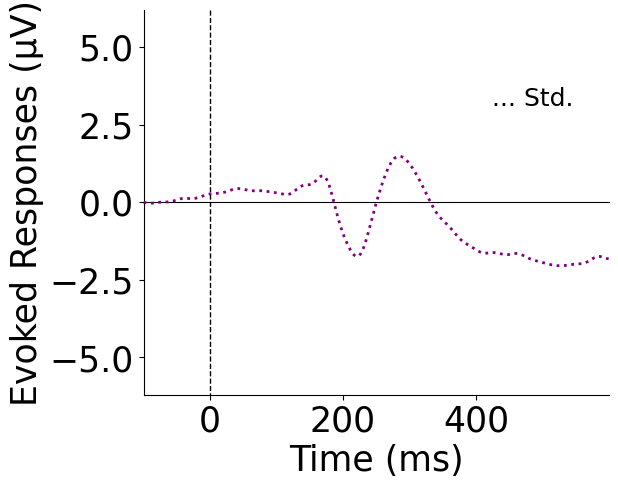

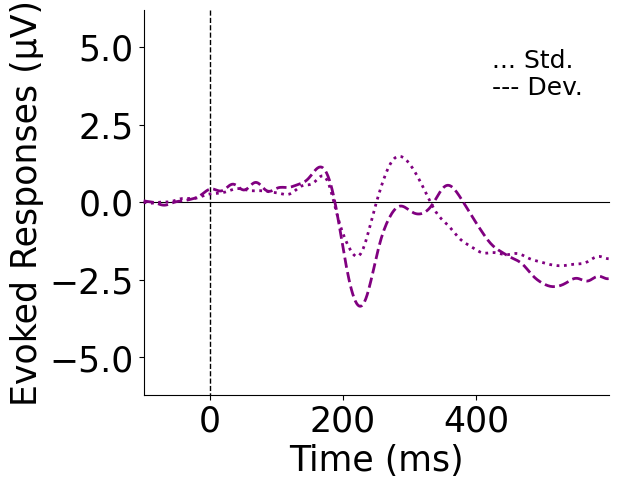

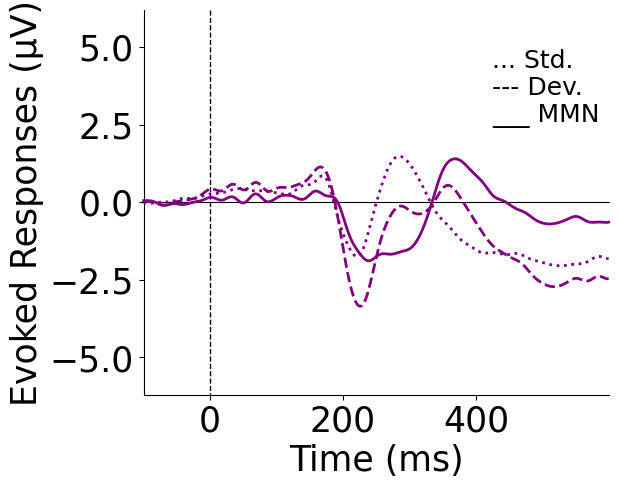

In [34]:
picks= ['F3', 'Cz', 'F4',]
# Define the start and end time for the window 
start_time = -0.1  # Start of time window in seconds
end_time = 0.6
# End of time window
# ### Personalized siginificant ERP for all the categories
evokeds = {
    'Non PS std':B1_sta_combined_erp,
           
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)

stylesdict ={
             'Non PS std' : {"linewidth": 2,"linestyle":'dotted'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',  
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.750, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('Evoked Responses (µV)')
 
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
           'Non Ps deviant': B2_devi_combined_erp,
           'Non PS std':B1_sta_combined_erp,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={'Non Ps deviant': {"linewidth": 2,"linestyle":'--'},
             'Non PS std' : {"linewidth": 2,"linestyle":'dotted'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple','purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.85, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.78, f"--- Dev.", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('Evoked Responses (µV)')
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
           'Non Ps deviant': B2_devi_combined_erp,
           'Non PS std':B1_sta_combined_erp,
           'Non PS MMN': non_sign_MMN_erp,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={'Non Ps deviant': {"linewidth": 2,"linestyle":'--'},
             'Non PS std' : {"linewidth": 2,"linestyle":'dotted'},
             'Non PS MMN' :  {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple','purple','purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='')
axs.text( 0.75,0.85, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.78, f"--- Dev.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.71, f"___ MMN", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('Evoked Responses (µV)')
plt.rcParams.update({
    'xtick.labelsize': 18,  # X-axis tick labels font size
    'ytick.labelsize': 18,  # Y-axis tick labels font size
    'axes.labelsize': 18,   # Axis label font size
    'axes.titlesize': 18,   # Title font size 
    'legend.fontsize': 18,   # Legend font size
})
plt.show( )# export it 

### Personal significNCE (smartphone notification )  MMN ERP

combining channels using "mean"


combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1271207086.py:22: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1271207086.py:47: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green','green'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\1271207086.py:74: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green','green','green'],show_sensors=False,legend=False,


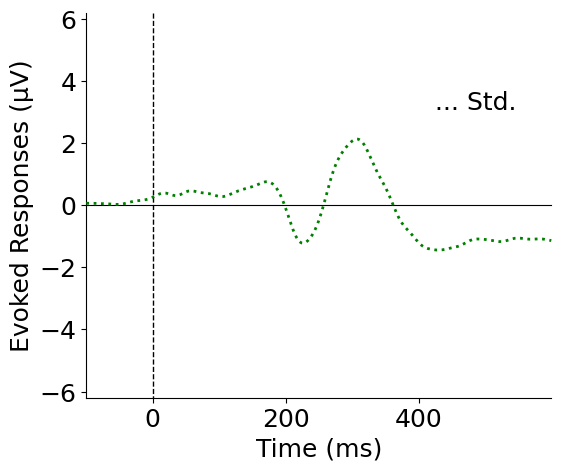

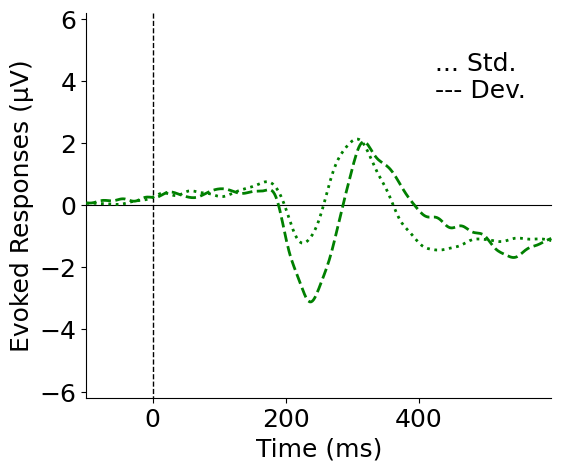

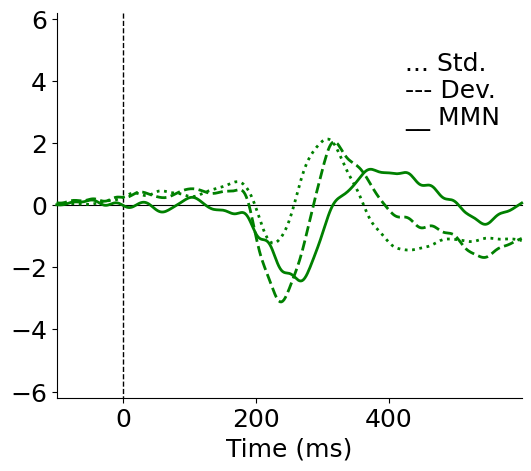

In [35]:
# ### Personalized siginificant ERP for all the categories
picks= ['F3', 'Cz', 'F4',]
evokeds = {
    'PS std':B2_sta_combined_erp,
           
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)

stylesdict ={
             'PS std' : {"linewidth": 2,"linestyle":'dotted'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.750, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('Evoked Responses (µV)')
 
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
           'Ps deviant': B1_devi_combined_erp,
           'PS std':B2_sta_combined_erp,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={'Ps deviant': {"linewidth": 2,"linestyle":'--'},
             'PS std' : {"linewidth": 2,"linestyle":'dotted'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green','green'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.85, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.78, f"--- Dev.", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('Evoked Responses (µV)')
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
           'Ps deviant': B1_devi_combined_erp,
           'PS std':B2_sta_combined_erp,
           'PS MMN': Personal_MMN_erp,
                      }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={'Ps deviant': {"linewidth": 2,"linestyle":'--'},
             'PS std' : {"linewidth": 2,"linestyle":'dotted'},
             'PS MMN' :  {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green','green','green'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='')
axs.text( 0.75,0.85, f"... Std.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.78, f"--- Dev.", transform=axs.transAxes, fontsize=18)
axs.text( 0.75,0.71, f"__ MMN", transform=axs.transAxes, fontsize=18)
axs.set_ylabel('')
plt.rcParams.update({
    'xtick.labelsize': 18,  # X-axis tick labels font size
    'ytick.labelsize': 18,  # Y-axis tick labels font size
    'axes.labelsize': 18,   # Axis label font size
    'axes.titlesize': 18,   # Title font size 
    'legend.fontsize': 18,   # Legend font size
})
plt.show( )# export it 

combining channels using "mean"


combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\3767376524.py:21: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\3767376524.py:46: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green', 'Purple'],show_sensors=False,legend=False,


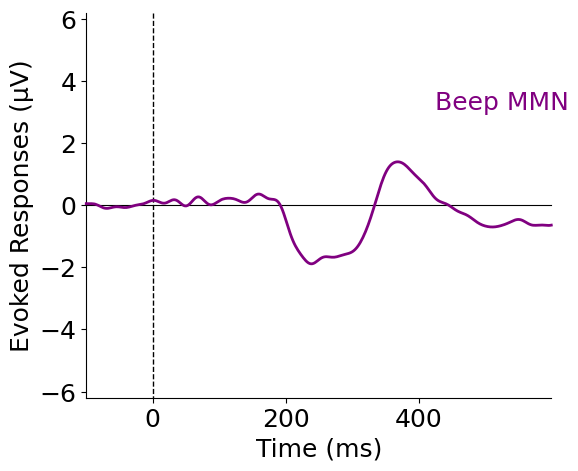

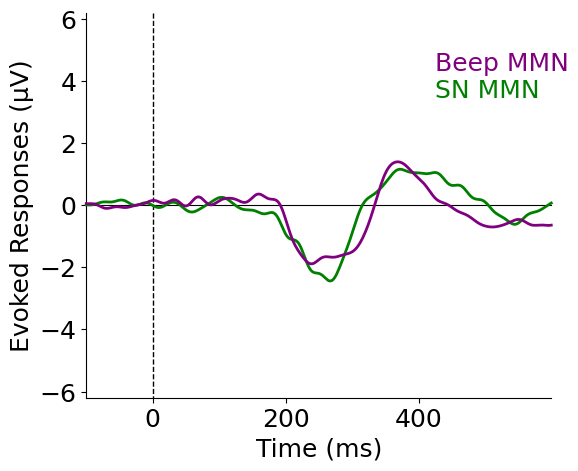

In [36]:

# ### Personalized siginificant ERP for all the categories
evokeds = {
    'NPS MMN':non_sign_MMN_erp,
           
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)

stylesdict ={
             'NPS MMN' : {"linewidth": 2,"linestyle":'solid',},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.750, f"Beep MMN", transform=axs.transAxes, fontsize=18, color='purple')
axs.set_ylabel('Evoked Responses (µV)')
 
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
    "PS MMN" : Personal_MMN_erp,
    'NPS MMN':non_sign_MMN_erp,
           }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={"PS MMN": {"linewidth": 2,"linestyle":'solid'},
             'NPS MMN' : {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green', 'Purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='')
axs.text( 0.75,0.85, f"Beep MMN", transform=axs.transAxes, fontsize=18, color='Purple')
axs.text( 0.75,0.78, f"SN MMN", transform=axs.transAxes, fontsize=18, color='green')
axs.set_ylabel('Evoked Responses (µV)')
plt.rcParams.update({
    'xtick.labelsize': 18,  # X-axis tick labels font size
    'ytick.labelsize': 18,  # Y-axis tick labels font size
    'axes.labelsize': 18,   # Axis label font size
    'axes.titlesize': 18,   # Title font size 
    'legend.fontsize': 18,   # Legend font size
})
# Plot the evoked responses

# Smartphone usage based group

In [49]:
import pandas as pd
subject_info= pd.read_excel(r"E:\ecf-exp2-notif-mmn\data\Processed\ECF_smartphone_survey.xlsx")
subject_info.head()

,Timestamp,Email Address,Subject ID,Age,Gender,Occupation,Education,I can never spend enough time on my mobile phone.,I have used my mobile phone to make myself feel better when I was feeling down.,"I find myself occupied on my mobile phone when I should be doing other things, and it causes problems.",...,How did you feel about the notifications during the 2nd half of the experiment?,My phone is on [Silent / DND].1,My phone is on [Sometimes],My phone is on [Most of the times],My phone is on [Always],My phone is on [Vibrate only].1,My phone is on [Loud].1,Do you receive notifications on some other device instead (like a smartwatch)?,MPPUS,SAS
0,2024-05-15 11:36:03.174000,sgandhi@iitj.ac.in,sub002,NaN,NaN,NaN,NaN,3,7,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60,50
1,2024-05-27 17:36:20.547000,tanvi.gandhi.ajmer@gmail.com,sub003,NaN,NaN,NaN,NaN,8,9,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,176,130
2,2024-05-28 13:42:27.613000,rishabh1000khandelwal@gmail.com,sub004,NaN,NaN,NaN,NaN,5,10,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,124,107
3,2024-05-29 19:50:37.592000,m23air013@iitj.ac.in,sub005,NaN,NaN,NaN,NaN,2,10,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,140,106
4,2024-05-31 18:33:04.260000,anikde@iitj.ac.in,sub006,NaN,NaN,NaN,NaN,8,7,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,107,60


In [50]:
subject_info["avg_S"] = subject_info[['MPPUS',	'SAS'	]].mean(axis=1)
#subject_info_D=subject_info[subject_info["Subject ID"].str.contains("SD")]
#subject_info_D
subject_info_D=subject_info.copy()
subject_info_D

,Timestamp,Email Address,Subject ID,Age,Gender,Occupation,Education,I can never spend enough time on my mobile phone.,I have used my mobile phone to make myself feel better when I was feeling down.,"I find myself occupied on my mobile phone when I should be doing other things, and it causes problems.",...,My phone is on [Silent / DND].1,My phone is on [Sometimes],My phone is on [Most of the times],My phone is on [Always],My phone is on [Vibrate only].1,My phone is on [Loud].1,Do you receive notifications on some other device instead (like a smartwatch)?,MPPUS,SAS,avg_S
0,2024-05-15 11:36:03.174000,sgandhi@iitj.ac.in,sub002,NaN,NaN,NaN,NaN,3,7,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60,50,55.0
1,2024-05-27 17:36:20.547000,tanvi.gandhi.ajmer@gmail.com,sub003,NaN,NaN,NaN,NaN,8,9,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,176,130,153.0
2,2024-05-28 13:42:27.613000,rishabh1000khandelwal@gmail.com,sub004,NaN,NaN,NaN,NaN,5,10,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,124,107,115.5
3,2024-05-29 19:50:37.592000,m23air013@iitj.ac.in,sub005,NaN,NaN,NaN,NaN,2,10,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,140,106,123.0
4,2024-05-31 18:33:04.260000,anikde@iitj.ac.in,sub006,NaN,NaN,NaN,NaN,8,7,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,107,60,83.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,3/30/2025 18:08:46,ankitmathurmohammadi@gmail.com,SD057,NaN,NaN,NaN,NaN,6,8,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,140,101,120.5
340,3/30/2025 20:50:27,prataprajsingh6@gmail.com,Sd058,NaN,NaN,NaN,NaN,4,10,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,151,112,131.5
341,3/30/2025 23:17:51,NaN,SD059,NaN,NaN,NaN,NaN,3,9,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,191,154,172.5
342,2025-01-04 19:55:16,rahulenviitd@gmail.com,SD060,NaN,NaN,NaN,NaN,5,9,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,147,98,122.5


Shapiro-Wilk Test for MPPUS: ShapiroResult(statistic=0.9934500846396134, pvalue=0.1412644922092764)
Shapiro-Wilk Test for SAS: ShapiroResult(statistic=0.9922694088617041, pvalue=0.07129202190783392)
Shapiro-Wilk Test for Avg: ShapiroResult(statistic=0.9905479442342819, pvalue=0.02611383220998405)


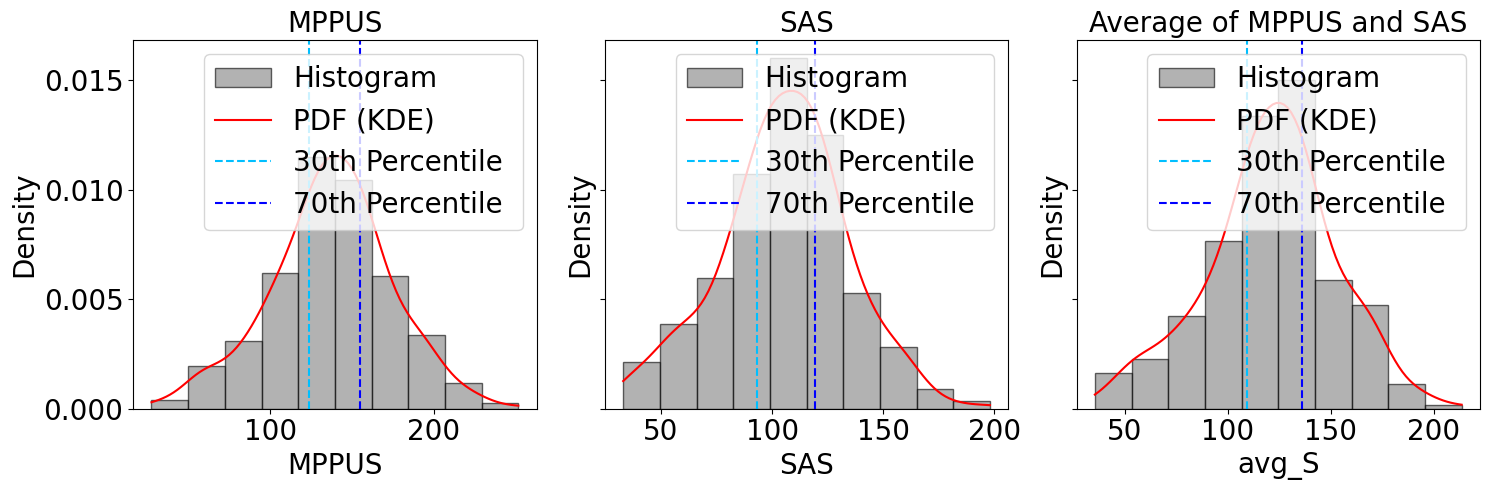

In [51]:
from scipy.stats import shapiro, kstest
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
# Shapiro-Wilk test
shapiro_mppus = shapiro(subject_info_D['MPPUS'])
shapiro_sas = shapiro(subject_info_D['SAS'])
shapiro_avg_s = shapiro(subject_info_D['avg_S'])
print("Shapiro-Wilk Test for MPPUS:", shapiro_mppus)
print("Shapiro-Wilk Test for SAS:", shapiro_sas)
print("Shapiro-Wilk Test for Avg:", shapiro_avg_s )




# Set up the figure for subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
columns = ['MPPUS',	'SAS', 'avg_S']
titles = ['MPPUS', 'SAS', 'Average of MPPUS and SAS']

# Loop through columns to plot
for ax, column, title in zip(axes, columns, titles):
    # Data for the column
    data = subject_info_D[column]
    # Calculate quantiles
    q1 = subject_info_D[column].quantile(0.30)  # 25th percentil
    q3 = subject_info_D[column].quantile(0.70)  # 75th percentile
    # Plot histogram with density=True (normalized to PDF)
    ax.hist(data, bins=10, density=True, alpha=0.6, color='grey',edgecolor='black', label='Histogram')
    
    # Add Gaussian KDE for smooth curve
    kde = gaussian_kde(data)
    x_vals = np.linspace(data.min(), data.max(), 100)
    ax.plot(x_vals, kde(x_vals), color='red', label='PDF (KDE)')
    ax.axvline(q1, color='deepskyblue', linestyle='--', label='30th Percentile ')
    ax.axvline(q3, color='blue', linestyle='--', label='70th Percentile ')
    # Formatting
    ax.set_title(title)
    ax.set_xlabel(column)
    ax.set_ylabel('Density')
    ax.legend()

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [52]:
from scipy.stats import pearsonr

# Calculate correlation coefficient
corr_coeff, _ = pearsonr(subject_info_D['MPPUS'], subject_info_D['SAS'])
print(corr_coeff)

0.7904424291223553


In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Calculate 30th and 70th percentiles for SAS
sas_30 = subject_info_D['SAS'].quantile(0.30) 
sas_70 = subject_info_D['SAS'].quantile(0.70) 

# Create figure and axes

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True, gridspec_kw={'width_ratios': [1, 1]},dpi =1000)  # Share y-axis for alignment
scatter_ax, hist_ax = axes

# === First subplot: Correlation Scatter Plot === #
# Color code based on SAS percentiles
colors = np.where(subject_info_D['SAS'] >= sas_70, 'darkorange', 
                  np.where(subject_info_D['SAS'] <= sas_30,'deepskyblue', 'black'))
colors = colors.tolist()
# Scatter plot
#scatter_ax.scatter(subject_info_D['MPPUS score'], subject_info_D['SAS score'], c=colors, alpha=0.8, edgecolor='k', s=70)
# Scatter plot with regression line (on the right subplot)
sns.regplot(x = subject_info_D['MPPUS'], y= subject_info_D['SAS'], ax=scatter_ax,
            scatter_kws={"color": colors, "s": 70, "edgecolor": "black"},line_kws=dict(color="grey",alpha=0.8,linewidth = 3)  )

scatter_ax.text(0.75, 0.65, f"r = {corr_coeff:.2f}", transform=scatter_ax.transAxes, fontsize=20, color='black')
scatter_ax.set_xlabel('MPPUS')
scatter_ax.set_ylabel('SAS')
scatter_ax.axhline(sas_30, color='deepskyblue', linestyle='solid',linewidth = 3, label='30th Percentile')
scatter_ax.axhline(sas_70, color='darkorange', linestyle='solid', linewidth = 3, label='70th Percentile')
# Add legend
scatter_ax.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='darkorange', markersize=10, label='HSU Group'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='deepskyblue', markersize=10, label='LSU Group'),
    #plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=10, label='Avg. Smartphone User Group'),
], loc='upper left',handletextpad=0.2)
# === Second subplot: SAS Histogram === #
hist_ax.hist(subject_info_D['SAS'], bins=10, alpha=0.4,  color='grey',orientation='horizontal',edgecolor='black')

hist_ax.axhline(sas_30, color='deepskyblue', linestyle='solid',linewidth = 3, label='30th Percentile')
hist_ax.axhline(sas_70, color='darkorange', linestyle='solid', linewidth = 3, label='70th Percentile')

hist_ax.set_xlabel('Count')
hist_ax.legend()
# Remove space between plots
for s,spine in enumerate(axes[0].spines.values()):
    if s !=0 and s != 2 :
        print(s,spine)
        spine.set_visible(False)
# Remove space between plots
for s,spine in enumerate(axes[1].spines.values()):
    if s !=2 :
        print(s,spine)
        spine.set_visible(False)
plt.subplots_adjust(wspace=0.0)
# Adjust layout and show plot
plt.tight_layout()
plt.rcParams.update({
    'xtick.labelsize': 15,  # X-axis tick labels font size
    'ytick.labelsize': 15,  # Y-axis tick labels font size
    'axes.labelsize': 15,   # Axis label font size
    'axes.titlesize': 15,   # Title font size
    'legend.fontsize': 15,   # Legend font size
})
plt.show()


1 Spine
3 Spine
0 Spine
1 Spine
3 Spine


0


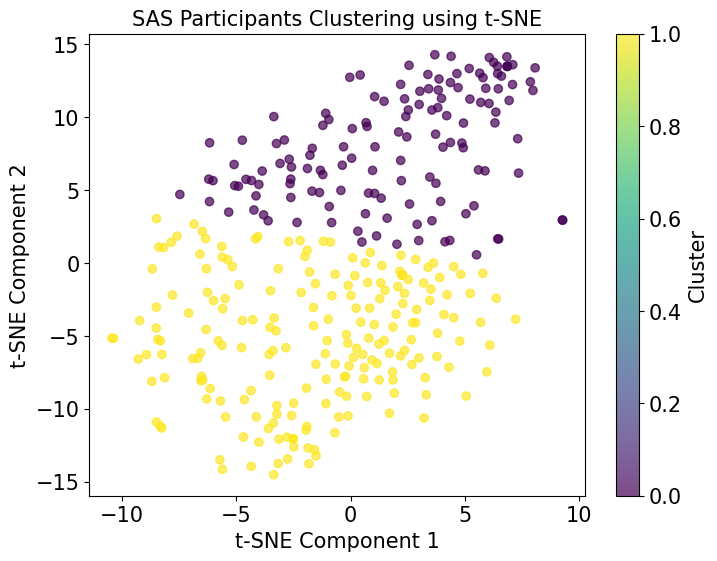

Silhouette Score: 0.47


In [54]:

from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.preprocessing import StandardScaler
df_selected = subject_info_D.iloc[:, 34:67]
df_selected
print(df_selected.isna().sum().sum())
scaler = StandardScaler()
df_standardized = pd.DataFrame(scaler.fit_transform(df_selected), columns=df_selected.columns)



#  Apply t-SNE for dimensionality reduction
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(df_standardized )

# Apply K-means clustering
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_tsne)

# Add cluster labels to the original dataframe
df_selected["Cluster"] = clusters

# Visualize the clusters
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters, cmap="viridis", alpha=0.7)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("SAS Participants Clustering using t-SNE")
plt.colorbar(label="Cluster")
plt.show()

# Step 6: Evaluate clustering performance
silhouette_avg = silhouette_score(X_tsne, clusters)
print(f"Silhouette Score: {silhouette_avg:.2f}")


c:\Users\PRAKASH\AppData\Local\anaconda3\envs\EEG_analysis\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


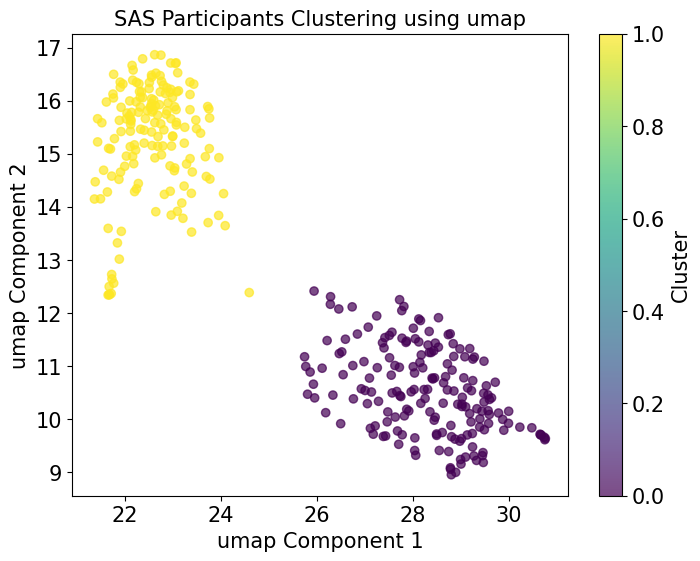

Silhouette Score: 0.29


In [55]:
import umap

umap_model = umap.UMAP(n_components=2,metric = 'chebyshev', random_state=42,n_epochs = 500,min_dist = 0.1)
X_umap = umap_model.fit_transform(df_standardized)



# Apply K-means clustering
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_umap)


df_selected["Cluster"] = clusters

# Visualize the clusters
plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=clusters, cmap="viridis", alpha=0.7)
plt.xlabel("umap Component 1")
plt.ylabel("umap Component 2")
plt.title("SAS Participants Clustering using umap")
plt.colorbar(label="Cluster")
plt.show()

silhouette_avg = silhouette_score(X_tsne, clusters)
print(f"Silhouette Score: {silhouette_avg:.2f}")


In [56]:
subject_info_D['SAS_clus']=clusters
subject_info_D=subject_info_D[subject_info_D["Subject ID"].str.contains("SD")]

1 Spine
3 Spine


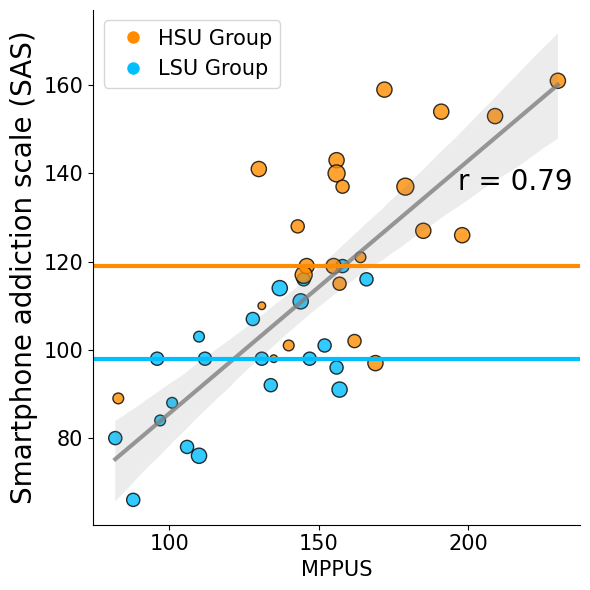

In [57]:
# Example mapping
response_map = {
    'Strongly disagree': 30,
    'Disagree': 60,
    'Neutral': 90,
    'Agree': 120,
    'Strongly agree': 150
}
sizes = subject_info_D['How much do you agree with the statement: I am addicted to my smartphone?'].map(response_map)





# Calculate 30th and 70th percentiles for SAS
sas_30 = subject_info_D['SAS'].quantile(0.30) 
sas_70 = subject_info_D['SAS'].quantile(0.70) 

# Create figure and axes

fig, axes = plt.subplots(1, 1, figsize=(6, 6),dpi =100)  # Share y-axis for alignment
scatter_ax = axes

# === First subplot: Correlation Scatter Plot === #
# Color code based on SAS percentiles
colors = np.where(subject_info_D['SAS_clus'] == 0 , 'darkorange', 
                  np.where(subject_info_D['SAS_clus'] == 1,'deepskyblue', 'black'))
colors = colors.tolist()
# Scatter plot
#scatter_ax.scatter(subject_info_D['MPPUS score'], subject_info_D['SAS score'], c=colors, alpha=0.8, edgecolor='k', s=70)
# Scatter plot with regression line (on the right subplot)
sns.regplot(x = subject_info_D['MPPUS'], y= subject_info_D['SAS'], ax=scatter_ax,
            scatter_kws={"color": colors, "s": sizes, "edgecolor": "black"},line_kws=dict(color="grey",alpha=0.8,linewidth = 3)  )

scatter_ax.text(0.75, 0.65, f"r = {corr_coeff:.2f}", transform=scatter_ax.transAxes, fontsize=20, color='black')
scatter_ax.set_xlabel('MPPUS')
scatter_ax.set_ylabel('Smartphone addiction scale (SAS)',fontsize=20)
scatter_ax.axhline(sas_30, color='deepskyblue', linestyle='solid',linewidth = 3, label='30th Percentile')
scatter_ax.axhline(sas_70, color='darkorange', linestyle='solid', linewidth = 3, label='70th Percentile')
# Add legend
scatter_ax.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='darkorange', markersize=10, label='HSU Group'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='deepskyblue', markersize=10, label='LSU Group'),
    #plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=10, label='Avg. Smartphone User Group'),
], loc='upper left',handletextpad=0.2)

# === Second subplot: SAS Histogram === #
# Remove space between plots
for s,spine in enumerate(axes.spines.values()):
    if s !=0 and s != 2 : 
        print(s,spine)
        spine.set_visible(False)

plt.subplots_adjust(wspace=0.0)
# Adjust layout and show plot
plt.tight_layout()
plt.rcParams.update({
    'xtick.labelsize': 20,  # X-axis tick labels font size
    'ytick.labelsize': 20,  # Y-axis tick labels font size
    'axes.labelsize': 20,   # Axis label font size
    'axes.titlesize': 20,   # Title font size
    'legend.fontsize': 20,   # Legend font size
})
plt.show()


In [58]:
# low samrtphone user 
subject_info_D_low = subject_info_D[subject_info_D['SAS_clus']==1]
# high smartphone user 
subject_info_D_high = subject_info_D[subject_info_D['SAS_clus']==0]
# catogory subject list 
low_sub_D = list(subject_info_D_low['Subject ID'])

high_sub_D = list(subject_info_D_high['Subject ID'])


### LSU and HSU MMN

In [59]:
B1_devi_eps_evoked_list_low = [B1_devi_eps_evoked_dict[sub]  for sub in B1_devi_eps_evoked_dict if sub in low_sub_D]
B1_devi_combined_erp_low = mne.grand_average(B1_devi_eps_evoked_list_low)
 
B1_sta_eps_evoked_list_low = [B1_sta_eps_evoked_dict[sub]  for sub in B1_sta_eps_evoked_dict if sub in low_sub_D ]
B1_sta_combined_erp_low = mne.grand_average(B1_sta_eps_evoked_list_low ) 

B2_devi_eps_evoked_list_low = [B2_devi_eps_evoked_dict[sub]  for sub in B2_devi_eps_evoked_dict if sub in low_sub_D ]
B2_devi_combined_erp_low = mne.grand_average(B2_devi_eps_evoked_list_low)

B2_sta_eps_evoked_list_low = [B2_sta_eps_evoked_dict[sub]  for sub in B2_sta_eps_evoked_dict if sub in low_sub_D  ]
B2_sta_combined_erp_low = mne.grand_average(B2_sta_eps_evoked_list_low )     

Personal_MMN_erp_low = mne.combine_evoked([B1_devi_combined_erp_low ,B2_sta_combined_erp_low], weights=[1,-1])

non_sign_MMN_erp_low = mne.combine_evoked([B2_devi_combined_erp_low,B1_sta_combined_erp_low], weights=[1,-1])  


Identifying common channels ...


Identifying common channels ...
Identifying common channels ...
Identifying common channels ...


combining channels using "mean"


combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\2291197033.py:20: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green', 'Purple'],show_sensors=False,legend=False,


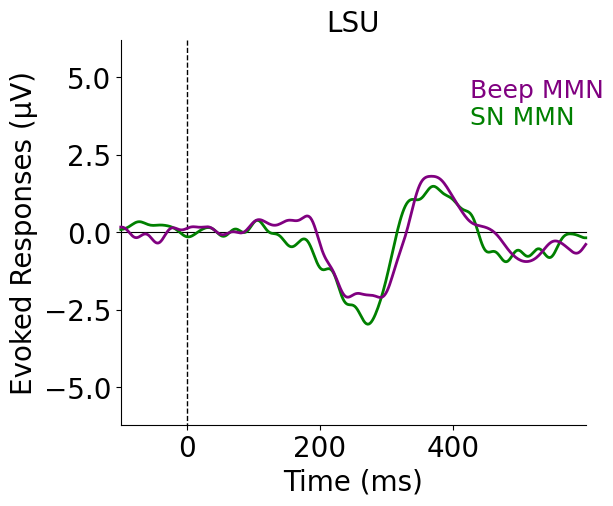

In [60]:
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
    "PS MMN" : Personal_MMN_erp_low,
    'NPS MMN':non_sign_MMN_erp_low,
           }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={"PS MMN": {"linewidth": 2,"linestyle":'solid'},
             'NPS MMN' : {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green', 'Purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='LSU')
axs.text( 0.75,0.85, f"Beep MMN", transform=axs.transAxes, fontsize=18, color='Purple')
axs.text( 0.75,0.78, f"SN MMN", transform=axs.transAxes, fontsize=18, color='green')
axs.set_ylabel('Evoked Responses (µV)')
plt.rcParams.update({
    'xtick.labelsize': 18,  # X-axis tick labels font size
    'ytick.labelsize': 18,  # Y-axis tick labels font size
    'axes.labelsize': 18,   # Axis label font size
    'axes.titlesize': 18,   # Title font size 
    'legend.fontsize': 18,   # Legend font size
})

In [61]:
B1_devi_eps_evoked_list_high = [B1_devi_eps_evoked_dict[sub]  for sub in B1_devi_eps_evoked_dict if sub in high_sub_D]
B1_devi_combined_erp_high= mne.grand_average(B1_devi_eps_evoked_list_high)
 
B1_sta_eps_evoked_list_high = [B1_sta_eps_evoked_dict[sub]  for sub in B1_sta_eps_evoked_dict if sub in high_sub_D ]
B1_sta_combined_erp_high = mne.grand_average(B1_sta_eps_evoked_list_high ) 

B2_devi_eps_evoked_list_high = [B2_devi_eps_evoked_dict[sub]  for sub in B2_devi_eps_evoked_dict if sub in high_sub_D ]
B2_devi_combined_erp_high = mne.grand_average(B2_devi_eps_evoked_list_high)

B2_sta_eps_evoked_list_high = [B2_sta_eps_evoked_dict[sub]  for sub in B2_sta_eps_evoked_dict if sub in high_sub_D  ]
B2_sta_combined_erp_high = mne.grand_average(B2_sta_eps_evoked_list_high )     

Personal_MMN_erp_high = mne.combine_evoked([B1_devi_combined_erp_high ,B2_sta_combined_erp_high], weights=[1,-1])

non_sign_MMN_erp_high = mne.combine_evoked([B2_devi_combined_erp_high,B1_sta_combined_erp_high], weights=[1,-1])  

Identifying common channels ...


Identifying common channels ...
Identifying common channels ...
Identifying common channels ...


combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\4080833218.py:20: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green', 'Purple'],show_sensors=False,legend=False,


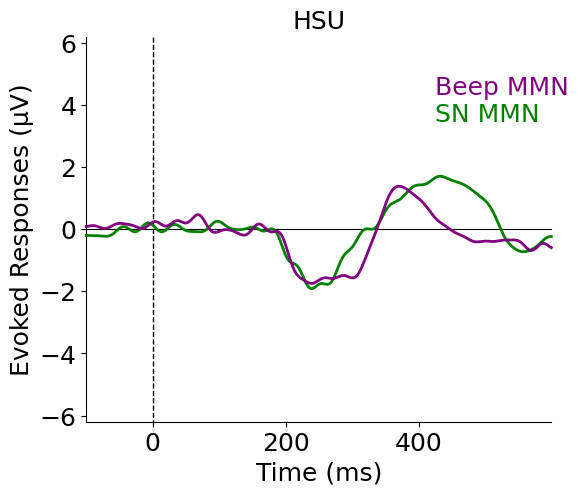

In [62]:
# Plot the evoked responses
fig,axs = plt.subplots(1,figsize=(6, 5), dpi =100)
evokeds = {
    "PS MMN" : Personal_MMN_erp_high,
    'NPS MMN':non_sign_MMN_erp_high,
           }
# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop



stylesdict ={"PS MMN": {"linewidth": 2,"linestyle":'solid'},
             'NPS MMN' : {"linewidth": 2,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['green', 'Purple'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes = axs,ylim = dict(eeg=[-6.2,6.2]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False,show =False,title='HSU')
axs.text( 0.75,0.85, f"Beep MMN", transform=axs.transAxes, fontsize=18, color='Purple')
axs.text( 0.75,0.78, f"SN MMN", transform=axs.transAxes, fontsize=18, color='green')
axs.set_ylabel('Evoked Responses (µV)')
plt.rcParams.update({
    'xtick.labelsize': 18,  # X-axis tick labels font size
    'ytick.labelsize': 18,  # Y-axis tick labels font size
    'axes.labelsize': 18,   # Axis label font size
    'axes.titlesize': 18,   # Title font size 
    'legend.fontsize': 18,   # Legend font size
})

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\2383756477.py:20: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
C:\Users\PRAKASH\AppData\Local\Temp\ipykernel_7260\2383756477.py:40: RuntimeWarning: Only 1 channel in "picks"; cannot combine by method "mean".
  mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,


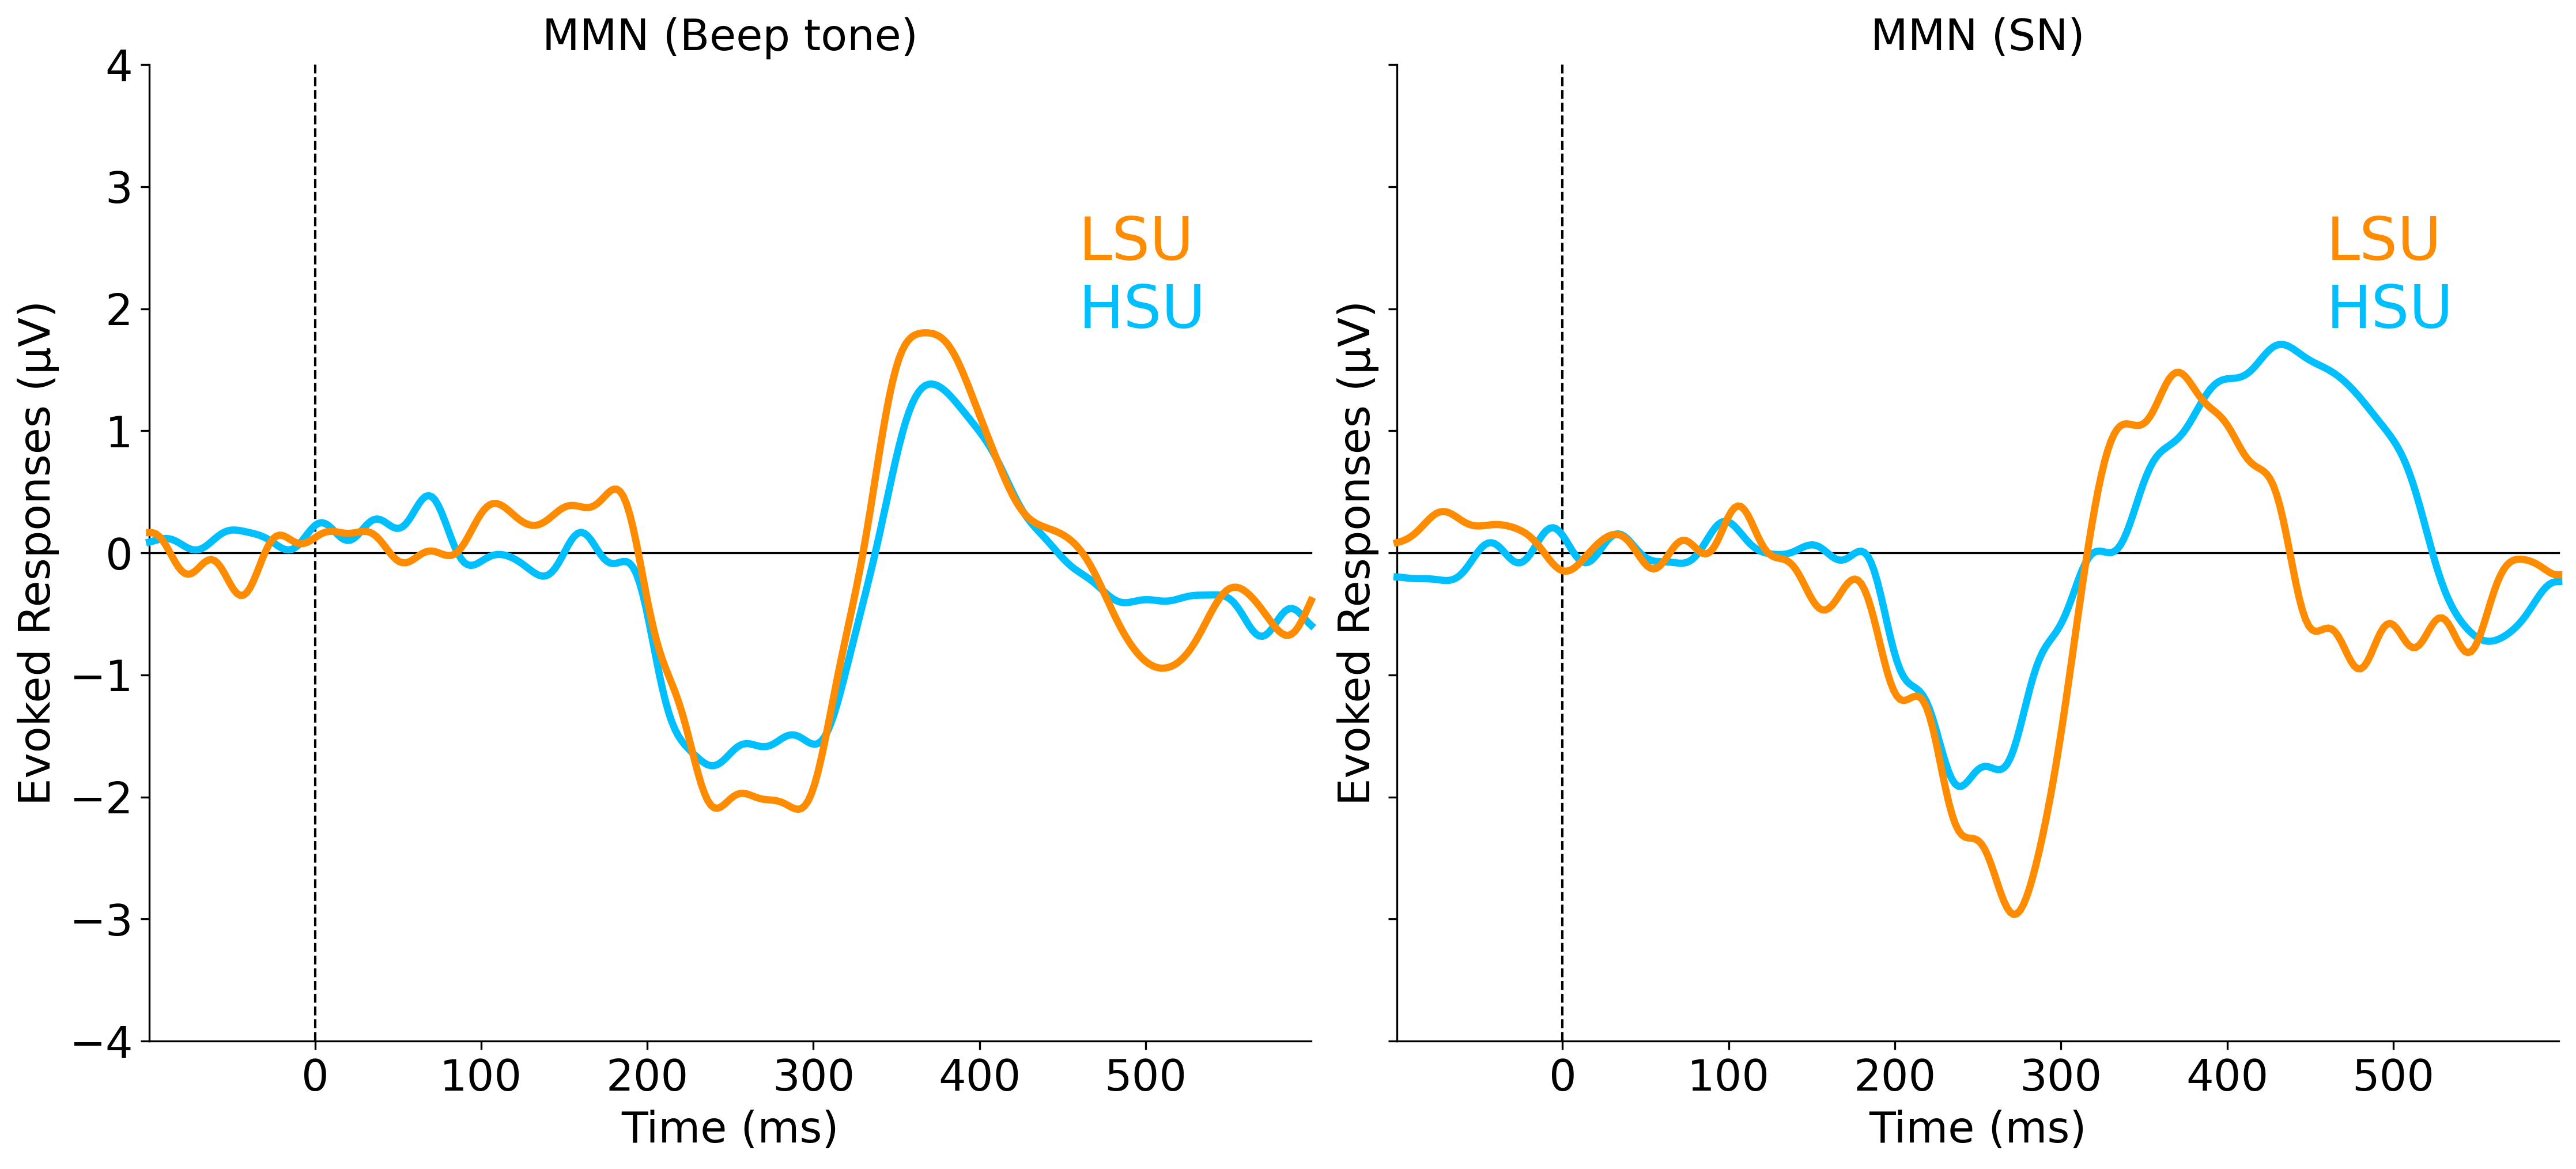

In [63]:
# ### Personalized siginificant ERP for all the categories
evokeds = {'HSU': Personal_MMN_erp_high,
           'LSU': Personal_MMN_erp_low,
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop

# Plot the evoked responses
fig,axs = plt.subplots(1, 2, figsize=(15, 7),  sharey=True, gridspec_kw={'width_ratios': [1, 1]},dpi =300)

stylesdict ={'HSU': {"linewidth": 3,"linestyle":'solid'},
             'LSU' : {"linewidth": 3,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs[1],ylim = dict(eeg=[-4,4]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='MMN (SN)')



# ### Non Personalized siginificant ERP for all the categories
evokeds = {'HSU': non_sign_MMN_erp_high,
           'LSU': non_sign_MMN_erp_low,
           }

# Subset the evoked data by selecting the time range
evokeds_subset = {}

for key, evoked in evokeds.items():
    # Apply the time range filter to each evoked object
    evoked_crop = evoked.copy().crop(tmin=start_time, tmax=end_time)
    evokeds_subset[key] = evoked_crop


mne.viz.plot_compare_evokeds(evokeds_subset, picks=picks[1],colors = ['deepskyblue','darkorange'],show_sensors=False,legend=False,
                                   styles=stylesdict, combine='mean',axes=axs[0],ylim = dict(eeg=[-4,4]),time_unit= 'ms',
                                   truncate_xaxis=False,truncate_yaxis=False ,show= False,title='MMN (Beep tone)')


# Add an overall title for the whole plot
#fig.suptitle('Low, Medium and High smartphone user  ', fontsize=30)
axs[0].text(0.80,  0.73,f"HSU", transform=axs[0].transAxes, fontsize=25, color='deepskyblue')
axs[0].text( 0.80,0.80, f"LSU", transform=axs[0].transAxes, fontsize=25, color='darkorange')

axs[1].text(0.80,0.73, f"HSU", transform=axs[1].transAxes, fontsize=25, color='deepskyblue')
axs[1].text( 0.80,0.80, f"LSU", transform=axs[1].transAxes, fontsize=25, color='darkorange')
# Add an overall title for the whole plot

# Add an arrow pointing to a specific point
"""axs[0].text(0.50, 0.05, f"N1", transform=axs[0].transAxes, fontsize=24, color='black')
axs[0].text( 0.62,0.8, f"P1", transform=axs[0].transAxes, fontsize=24, color='black')
# Add an arrow pointing to a specific point
axs[1].text(0.45, 0.05, f"N1", transform=axs[1].transAxes, fontsize=24, color='black')

axs[1].text( 0.58,0.60, f"P1", transform=axs[1].transAxes, fontsize=24, color='black')

axs[1].text( 0.75,0.68, f"P2", transform=axs[1].transAxes, fontsize=24, color='black')"""
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.tight_layout(rect=[0, 0, 1, 0.98])
axes = fig.axes  # List of subplot axes
axes[0].set_ylabel('Evoked Responses (µV)')
axes[1].set_ylabel('Evoked Responses (µV)')
"""for ax in axes[1:]:  # Skip the first subplot (index 0)
    ax.set_ylabel('')"""
plt.rcParams.update({
    'xtick.labelsize': 25,  # X-axis tick labels font size
    'ytick.labelsize': 25,  # Y-axis tick labels font size
    'axes.labelsize': 25,   # Axis label font size
    'axes.titlesize': 25,   # Title font size 
    'legend.fontsize': 25,   # Legend font size
})
plt.show()

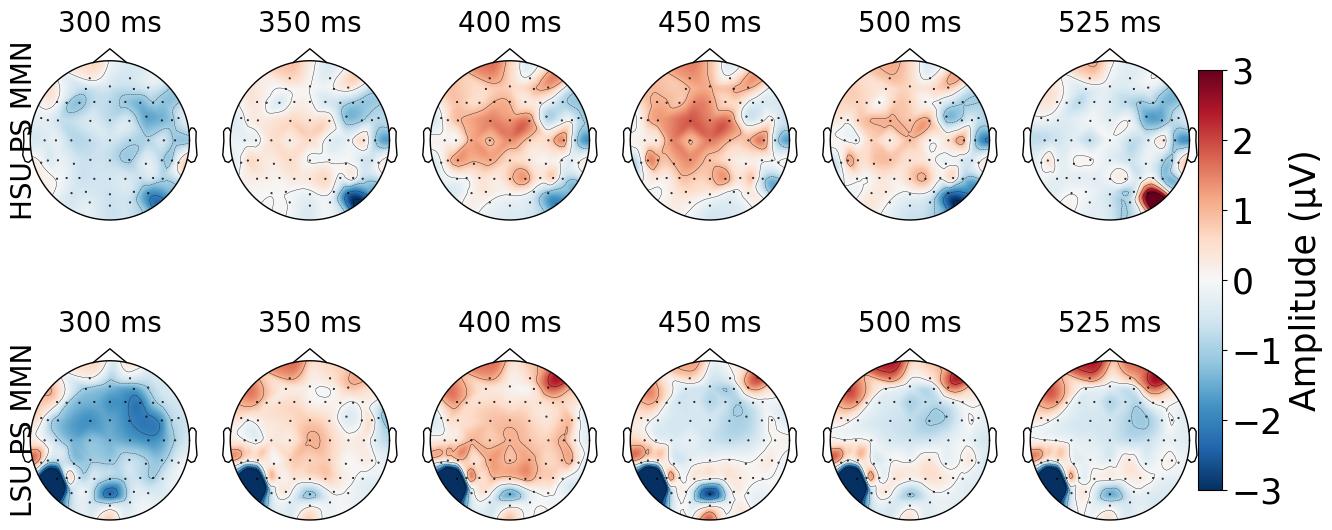

In [64]:
# TOPO MAP with all electrodes 

# TOPO MAP with all electrodes 
import matplotlib.pyplot as plt
import matplotlib as mpl
# Define time points
time_points = [.300,.350,.400, .45,.5,.525]

# Set the color scale range
vlim = (-3, 3)  # Adjust based on your data

# Create a grid of subplots
fig, axes = plt.subplots(2, len(time_points), figsize=(12, 6), constrained_layout=True)

# To store the last 'im' object for the colorbar
im = None

# Plot topomaps for the first evoked (Personal_MMN_erp)
for i, time in enumerate(time_points):
    Personal_MMN_erp_high.copy().drop_channels(["AF7", "FC3"]).plot_topomap(
        times=[time], axes=axes[0, i], colorbar=False, vlim=vlim, show=False
    )
    axes[0, i].set_title(f"{time * 1000:.0f} ms",fontsize=20)

# Plot topomaps for the second evoked (B1_MMN_erp)
for i, time in enumerate(time_points):
    im= Personal_MMN_erp_low.copy().drop_channels(["AF7","FC3"]).plot_topomap(
        times=[time], axes=axes[1, i], colorbar=False, vlim=vlim, show=False
    ) 
    axes[1, i].set_title(f"{time * 1000:.0f} ms",fontsize=20)

# Generate a shared colorbar
cbar_ax = fig.add_axes([0.99, 0.15, 0.02, 0.7])  # Position for the colorbar
norm = mpl.colors.Normalize(vmin=vlim[0], vmax=vlim[1])  # Normalize color scale
cmap = mpl.colormaps['RdBu_r']  # Choose a colormap (like 'RdBu_r')

# Add the colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, orientation='vertical', label='Amplitude (µV)')

# Add row labels
fig.text(0.0001, 0.75, 'HSU PS MMN', fontsize=20, rotation=90, va='center')
fig.text(0.0001, 0.25, 'LSU PS MMN', fontsize=20, rotation=90, va='center')

plt.show()